## MIMIC-IV + eICU Multi-Center Validation

Pipeline structure:
- **Steps 0-4**: Data download, cohort building, vital sign extraction, feature engineering
- **Step 5**: Train/val/test split
- **Step 6**: A(t) calibration on TRAIN ONLY (recalibrated weights, population statistics, hourly A(t))
- **Step 7**: XGBoost on 4 conditions (Full, NEWS2-set, CAS-4, CAS-4 hybrid A)
- **Step 8**: NEWS2 scoring baseline
- **Step 9**: Feature reduction curve (9 sensor levels) — central analysis
- **Step 10**: Additional models (CatBoost, Random Forest)
- **Step 11**: SHAP feature importance + ranking CSV
- **Step 12**: Calibration analysis (slope, CITL, Hosmer-Lemeshow)
- **Step 13**: Decision Curve Analysis with explicit NB at p_t=0.10
- **Step 14**: Subgroup analysis
- **Step 15**: eICU multi-center external validation (hourly A(t), 139 hospitals)
- **Step 16**: Save all results to JSON
- **Step 17**: Bootstrap pairwise AUROC comparison (n=2000)

All results → `~/mimic4_study/results/all_results.json` for Word template.

### v4 changelog (May 2026)
- A(t) weights and population statistics now computed on **training set only**
  (previously on full cohort — addressed test-set leakage concern).
- eICU A(t) now computed **hourly** matching MIMIC-IV methodology
  (previously simplified to `at_max=at_mean`, `at_std=0`).
- Bootstrap permutation test now executes as part of the pipeline.
- SHAP feature ranking exported to CSV alongside summary plot.
- DCA reports explicit net benefit at p_t=0.10 for each model.
- All paths use `os.path.expanduser` for portability.

---
## Step 0: Setup & Installation

In [1]:
# Install required packages (uncomment if needed, or run: pip install -r requirements.txt)
# !pip install pandas numpy pyarrow scikit-learn xgboost catboost shap matplotlib scipy tqdm wfdb requests

In [2]:
import os
import sys
import json
import warnings
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, average_precision_score, roc_curve,
    precision_recall_curve, brier_score_loss, f1_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from scipy import stats
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 11

print(f"Python: {sys.version}")
print(f"Pandas: {pd.__version__}")
print(f"NumPy: {np.__version__}")

Python: 3.12.9 | packaged by conda-forge | (main, Mar  4 2025, 22:44:42) [Clang 18.1.8 ]
Pandas: 2.3.3
NumPy: 2.4.4


In [3]:
# ============================================================
# CONFIGURATION
# ============================================================

# PhysioNet credentials — set via environment variable or edit here
PHYSIONET_USER = os.environ.get("PHYSIONET_USER", "")
if not PHYSIONET_USER:
    raise RuntimeError("Set the PHYSIONET_USER environment variable (your physionet.org login) before running this notebook.")

MIMIC_PACKAGE = "mimiciv"
MIMIC_VER = "3.1"

# All paths use expanduser for portability across machines
BASE_DIR = os.path.expanduser(os.environ.get("CAS_BASE_DIR", "~/mimic4_study"))
RAW_DIR = os.path.join(BASE_DIR, "raw")
PROCESSED_DIR = os.path.join(BASE_DIR, "processed")
RESULTS_DIR = os.path.join(BASE_DIR, "results")
MODELS_DIR = os.path.join(BASE_DIR, "models")
FIGURES_DIR = os.path.join(BASE_DIR, "figures")

RANDOM_STATE = 42

for d in [BASE_DIR, RAW_DIR, PROCESSED_DIR, RESULTS_DIR, MODELS_DIR, FIGURES_DIR]:
    os.makedirs(d, exist_ok=True)

print(f"Base directory: {BASE_DIR}")

assert PHYSIONET_USER and PHYSIONET_USER != "YOUR_PHYSIONET_USERNAME", \
    "Please set PHYSIONET_USER environment variable or edit this cell."

# A(t) clinical severity multipliers (fixed, from prior work [14])
# Weights are recalibrated empirically on training set in Step 6.
AT_MULTIPLIERS = {'resp_rate': 3.0, 'spo2': 2.0, 'heart_rate': 1.0, 'temperature': 1.0}

Base directory: ~/mimic4_study


In [4]:
# MIMIC-IV itemids for vital signs
VITAL_SIGN_ITEMS = {
    "heart_rate":   [220045],
    "spo2":         [220277],
    "resp_rate":    [220210, 224690],
    "temperature":  [223761, 223762],   # Fahrenheit and Celsius
    "sbp":          [220179, 220050],
    "dbp":          [220180, 220051],
    "map":          [220052, 220181, 225312],
    "gcs_total":    [198],
}

ALL_ITEMIDS = [iid for ids in VITAL_SIGN_ITEMS.values() for iid in ids]
ITEMID_TO_VITAL = {iid: v for v, ids in VITAL_SIGN_ITEMS.items() for iid in ids}

CORE_VITALS = ["heart_rate", "spo2", "resp_rate", "temperature"]

# Plausible ranges for data cleaning
PLAUSIBLE_RANGES = {
    "heart_rate": (20, 300),
    "spo2": (50, 100),
    "resp_rate": (2, 70),
    "temperature": (30, 42),
    "sbp": (40, 300),
    "dbp": (20, 200),
    "map": (30, 250),
    "gcs_total": (3, 15),
}

# Suffixes for temporal statistical features (defined once, used everywhere)
SUFFIXES = ["_mean", "_std", "_min", "_max", "_first", "_last", "_range", "_cv", "_trend"]

print(f"Core vitals: {CORE_VITALS}")
print(f"Total itemids to extract: {len(ALL_ITEMIDS)}")

Core vitals: ['heart_rate', 'spo2', 'resp_rate', 'temperature']
Total itemids to extract: 14


---
## FAST START: Load Cached Data

If you already ran the original pipeline and have processed files,
this cell loads them and skips Steps 1-4 (data extraction).

A(t) recalibration in Step 6 will still run on training set.

In [5]:
# Check for cached data from previous run
SKIP_EXTRACTION = False

_cohort_path = os.path.join(PROCESSED_DIR, 'cohort_final.csv')
_features_path = os.path.join(PROCESSED_DIR, 'features_xgboost.csv')
_hourly_path = os.path.join(PROCESSED_DIR, 'hourly_series.csv.gz')

if os.path.exists(_cohort_path) and os.path.exists(_features_path) and os.path.exists(_hourly_path):
    print('Found cached data from previous run:')
    cohort = pd.read_csv(_cohort_path)
    features = pd.read_csv(_features_path)
    hourly_full = pd.read_csv(_hourly_path, compression='gzip')

    # Drop any A(t) columns from cached features — they will be RECOMPUTED in Step 6
    # using train-only weights (v4 fix for data leakage).
    at_cols_to_drop = [c for c in ['at_mean', 'at_max', 'at_std', 'at_last'] if c in features.columns]
    if at_cols_to_drop:
        features = features.drop(columns=at_cols_to_drop)
        print(f'  Dropped cached A(t) columns: {at_cols_to_drop} (will be recomputed train-only)')

    # Detect target column
    if 'in_hospital_mortality' not in cohort.columns and 'hospital_expire_flag' in cohort.columns:
        cohort['in_hospital_mortality'] = cohort['hospital_expire_flag']
    if 'in_hospital_mortality' not in features.columns and 'in_hospital_mortality' in cohort.columns:
        features = features.merge(cohort[['stay_id','in_hospital_mortality']], on='stay_id', how='left')

    # Ensure age/gender in features
    for col in ['age', 'gender']:
        if col not in features.columns and col in cohort.columns:
            features = features.merge(cohort[['stay_id', col]], on='stay_id', how='left')
    if 'gender_binary' not in features.columns and 'gender' in features.columns:
        features['gender_binary'] = (features['gender'] == 'M').astype(int)

    print(f'  Cohort: {len(cohort)} stays')
    print(f'  Features: {features.shape}')
    print(f'  Hourly grid: {len(hourly_full)} rows')
    print(f'  Mortality: {cohort["in_hospital_mortality"].sum()} ({cohort["in_hospital_mortality"].mean():.1%})')

    SKIP_EXTRACTION = True
    print('\n>>> Steps 1-4 will be SKIPPED. Jump to Step 5 (train/val/test split).')
else:
    print(f'No cached data found in {PROCESSED_DIR}')
    print('Will run full extraction pipeline (Steps 1-4).')

Found cached data from previous run:
  Dropped cached A(t) columns: ['at_mean', 'at_max', 'at_std', 'at_last'] (will be recomputed train-only)
  Cohort: 51981 stays
  Features: (51981, 68)
  Hourly grid: 1247544 rows
  Mortality: 5172 (9.9%)

>>> Steps 1-4 will be SKIPPED. Jump to Step 5 (train/val/test split).


---
## Step 1: Download MIMIC-IV Tables from PhysioNet

We download only the tables we need, not the entire database.

**Note:** `chartevents.csv.gz` is ~6 GB. This step may take 30-60 minutes.

Set environment variable `PHYSIONET_PASSWORD` to avoid interactive prompt.

In [6]:
if SKIP_EXTRACTION:
    print('Cached data available. Skipping download.')
    # Still need session for eICU later (Step 15) — will prompt at that point if needed.
    session = None
else:
    import requests
    import getpass

    pw_env = os.environ.get("PHYSIONET_PASSWORD")
    if pw_env:
        password = pw_env
        print(f"Using PHYSIONET_PASSWORD from environment for {PHYSIONET_USER}")
    else:
        password = getpass.getpass(f"PhysioNet password for {PHYSIONET_USER}: ")

    session = requests.Session()
    login_url = "https://physionet.org/login/"
    resp = session.get(login_url)
    csrf = session.cookies.get("csrftoken", "")

    login_data = {"username": PHYSIONET_USER, "password": password,
                  "csrfmiddlewaretoken": csrf}
    resp = session.post(login_url, data=login_data, headers={"Referer": login_url})
    print(f"Login status: {resp.status_code}")

    REQUIRED_TABLES = {
        "hosp": ["admissions", "patients"],
        "icu":  ["icustays", "chartevents", "d_items"],
    }
    EXPECTED_SIZES = {  # MB, used to detect resumable/incomplete downloads
        "admissions": 10, "patients": 0.3, "icustays": 2,
        "chartevents": 5000, "d_items": 0.05,
    }
    base_url = f"https://physionet.org/files/{MIMIC_PACKAGE}/{MIMIC_VER}"

    for module, tables in REQUIRED_TABLES.items():
        for table in tables:
            filename = f"{table}.csv.gz"
            url = f"{base_url}/{module}/{filename}"
            outpath = os.path.join(RAW_DIR, module)
            os.makedirs(outpath, exist_ok=True)
            filepath = os.path.join(outpath, filename)

            existing_size = os.path.getsize(filepath) if os.path.exists(filepath) else 0
            min_expected = EXPECTED_SIZES.get(table, 0) * 0.8 * 1e6

            if existing_size > min_expected and min_expected > 0:
                print(f"  [SKIP] {module}/{filename} ({existing_size/1e6:.0f} MB)")
                continue

            print(f"  [DOWNLOAD] {module}/{filename} ...", end=" ", flush=True)
            try:
                headers_req = {}
                if existing_size > 0:
                    headers_req["Range"] = f"bytes={existing_size}-"
                resp = session.get(url, stream=True, headers=headers_req)
                if resp.status_code == 416:
                    print(f"\r  [DONE] {module}/{filename} ({existing_size/1e6:.0f} MB) - already complete")
                    continue
                resp.raise_for_status()

                if resp.status_code == 206:
                    total = existing_size + int(resp.headers.get("content-length", 0))
                    mode, downloaded = "ab", existing_size
                else:
                    total = int(resp.headers.get("content-length", 0))
                    mode, downloaded = "wb", 0

                with open(filepath, mode) as f:
                    for chunk in resp.iter_content(chunk_size=1024*1024):
                        f.write(chunk)
                        downloaded += len(chunk)
                        if total > 0:
                            pct = downloaded / total * 100
                            print(f"\r  [DOWNLOAD] {module}/{filename} ... {pct:.0f}% "
                                  f"({downloaded/1e6:.0f}/{total/1e6:.0f} MB)", end="", flush=True)
                print(f"\r  [DONE] {module}/{filename} ({os.path.getsize(filepath)/1e6:.0f} MB)" + " "*30)
            except Exception as e:
                print(f"\n  [ERROR] {e}")

Cached data available. Skipping download.


---
## Step 2: Extract Study Cohort

**Inclusion criteria:**
- Adult (age ≥ 18)
- At least 1 ICU stay ≥ 24 hours
- First ICU stay per patient only

**Outcome:** In-hospital mortality (binary)

In [7]:
if SKIP_EXTRACTION:
    print('Skipping cohort extraction (cached).')
else:
    print("Loading tables...")
    patients = pd.read_csv(os.path.join(RAW_DIR, "hosp", "patients.csv.gz"), compression="gzip")
    admissions = pd.read_csv(
        os.path.join(RAW_DIR, "hosp", "admissions.csv.gz"), compression="gzip",
        parse_dates=["admittime", "dischtime", "deathtime"]
    )
    icustays = pd.read_csv(
        os.path.join(RAW_DIR, "icu", "icustays.csv.gz"), compression="gzip",
        parse_dates=["intime", "outtime"]
    )

    print(f"  Patients: {len(patients)}")
    print(f"  Admissions: {len(admissions)}")
    print(f"  ICU stays: {len(icustays)}")

Skipping cohort extraction (cached).


In [8]:
if not SKIP_EXTRACTION:
    # Merge
    cohort = icustays.merge(patients, on="subject_id", how="left")
    cohort = cohort.merge(admissions, on=["subject_id", "hadm_id"], how="left")

    # Compute age
    cohort["admit_year"] = cohort["admittime"].dt.year
    cohort["age"] = cohort["anchor_age"] + (cohort["admit_year"] - cohort["anchor_year"])

    # ICU length of stay (hours)
    cohort["icu_los_hours"] = (cohort["outtime"] - cohort["intime"]).dt.total_seconds() / 3600

    # In-hospital mortality
    cohort["in_hospital_mortality"] = (
        cohort["deathtime"].notna() & (cohort["deathtime"] <= cohort["dischtime"])
    ).astype(int)

    print(f"Total ICU stays before filtering: {len(cohort)}")

In [9]:
if not SKIP_EXTRACTION:
    print("Applying criteria:")

    n = len(cohort)
    cohort = cohort[cohort["age"] >= 18]
    print(f"  Age >= 18: {n} -> {len(cohort)} (removed {n - len(cohort)})")

    n = len(cohort)
    cohort = cohort[cohort["icu_los_hours"] >= 24]
    print(f"  LOS >= 24h: {n} -> {len(cohort)} (removed {n - len(cohort)})")

    n = len(cohort)
    cohort = cohort.sort_values("intime").groupby("subject_id").first().reset_index()
    print(f"  First stay: {n} -> {len(cohort)} (removed {n - len(cohort)})")

    cohort_cols = ["subject_id", "hadm_id", "stay_id", "intime", "outtime",
                   "age", "gender", "icu_los_hours", "in_hospital_mortality"]
    cohort = cohort[cohort_cols].copy()
    cohort.to_csv(os.path.join(PROCESSED_DIR, "cohort.csv"), index=False)

    print(f"\nCohort: {len(cohort)} patients")
    print(f"Mortality: {cohort['in_hospital_mortality'].sum()} ({cohort['in_hospital_mortality'].mean()*100:.1f}%)")
    print(f"Age: {cohort['age'].median():.0f} (IQR {cohort['age'].quantile(.25):.0f}-{cohort['age'].quantile(.75):.0f})")
    print(f"Male: {(cohort['gender']=='M').sum()} ({(cohort['gender']=='M').mean()*100:.1f}%)")

---
## Step 3: Extract Vital Signs from chartevents

This is the slowest step. `chartevents` is processed in 5M-row chunks.

**Expected time:** 20-40 minutes

In [10]:
if not SKIP_EXTRACTION:
    stay_ids = set(cohort["stay_id"].values)
    intime_map = dict(zip(cohort["stay_id"], pd.to_datetime(cohort["intime"])))

    chartevents_path = os.path.join(RAW_DIR, "icu", "chartevents.csv.gz")
    assert os.path.exists(chartevents_path), f"File not found: {chartevents_path}"

    all_vitals = []
    chunk_size = 5_000_000

    reader = pd.read_csv(
        chartevents_path, compression="gzip", chunksize=chunk_size,
        usecols=["stay_id", "itemid", "charttime", "valuenum"],
        dtype={"stay_id": "Int64", "itemid": "Int64", "valuenum": float},
        parse_dates=["charttime"],
    )

    for chunk in tqdm(reader, desc="Processing chartevents"):
        mask = (
            chunk["stay_id"].isin(stay_ids) &
            chunk["itemid"].isin(ALL_ITEMIDS) &
            chunk["valuenum"].notna()
        )
        filtered = chunk[mask].copy()
        if len(filtered) == 0:
            continue

        filtered["vital"] = filtered["itemid"].map(ITEMID_TO_VITAL)
        filtered["intime"] = filtered["stay_id"].map(intime_map)
        filtered["hours_since_admit"] = (
            (filtered["charttime"] - filtered["intime"]).dt.total_seconds() / 3600
        )
        filtered = filtered[
            (filtered["hours_since_admit"] >= 0) &
            (filtered["hours_since_admit"] < 24)
        ]
        if len(filtered) > 0:
            all_vitals.append(filtered[["stay_id", "vital", "charttime", "hours_since_admit", "valuenum"]])

    vitals = pd.concat(all_vitals, ignore_index=True)
    print(f"\nTotal vital sign measurements: {len(vitals):,}")

In [11]:
if not SKIP_EXTRACTION:
    # Temperature: convert Fahrenheit to Celsius
    mask_f = (vitals["vital"] == "temperature") & (vitals["valuenum"] > 50)
    vitals.loc[mask_f, "valuenum"] = (vitals.loc[mask_f, "valuenum"] - 32) * 5 / 9
    print(f"Converted {mask_f.sum()} temperature values from F to C")

    before = len(vitals)
    for vital_name, (lo, hi) in PLAUSIBLE_RANGES.items():
        bad = (vitals["vital"] == vital_name) & (
            (vitals["valuenum"] < lo) | (vitals["valuenum"] > hi)
        )
        vitals = vitals[~bad]
    print(f"Removed {before - len(vitals)} implausible values")

    vitals.to_csv(os.path.join(PROCESSED_DIR, "vitals_raw.csv.gz"), index=False, compression="gzip")
    print(f"Saved: {os.path.join(PROCESSED_DIR, 'vitals_raw.csv.gz')}")

    print("\nVital sign counts:")
    print(vitals["vital"].value_counts().to_string())

---
## Step 4: Create Features

1. Resample to hourly intervals (0-23 hours)
2. Forward-fill gaps ≤ 3 hours
3. Compute 9 temporal statistical features per vital sign
4. Filter cohort: require all 4 core vitals with ≥ 6 non-null hours

In [12]:
if not SKIP_EXTRACTION:
    vitals["hour"] = vitals["hours_since_admit"].astype(int).clip(0, 23)

    hourly = (
        vitals.groupby(["stay_id", "vital", "hour"])["valuenum"]
        .mean()
        .reset_index()
    )

    hourly_pivot = hourly.pivot_table(
        index=["stay_id", "hour"], columns="vital", values="valuenum"
    ).reset_index()

    all_hours = pd.DataFrame({
        "hour": list(range(24)) * len(cohort),
        "stay_id": np.repeat(cohort["stay_id"].values, 24)
    })
    hourly_full = all_hours.merge(hourly_pivot, on=["stay_id", "hour"], how="left")
    hourly_full = hourly_full.sort_values(["stay_id", "hour"])

    for col in hourly_full.columns:
        if col in ["stay_id", "hour"]:
            continue
        hourly_full[col] = (
            hourly_full.groupby("stay_id")[col]
            .transform(lambda s: s.fillna(method="ffill", limit=3))
        )

    print(f"Hourly grid: {len(hourly_full)} rows ({len(hourly_full)//24} patients x 24 hours)")

In [13]:
if not SKIP_EXTRACTION:
    # Filter: require all 4 core vitals with >= 6 non-null hours
    completeness = (
        hourly_full.groupby("stay_id")[CORE_VITALS]
        .apply(lambda df: (df.notna().sum() >= 6).all())
    )
    valid_stays = completeness[completeness].index.tolist()

    cohort = cohort[cohort["stay_id"].isin(valid_stays)].copy()
    hourly_full = hourly_full[hourly_full["stay_id"].isin(valid_stays)].copy()

    print(f"Patients with complete core vitals: {len(cohort)}")
    print(f"Mortality rate: {cohort['in_hospital_mortality'].mean():.3f}")

In [14]:
if not SKIP_EXTRACTION:
    all_vitals_names = [v for v in VITAL_SIGN_ITEMS.keys() if v in hourly_full.columns]

    feature_rows = []
    for stay_id, group in tqdm(hourly_full.groupby("stay_id"), desc="Computing features"):
        row = {"stay_id": stay_id}
        for vital in all_vitals_names:
            vals = group[vital].dropna()
            if len(vals) == 0:
                continue
            row[f"{vital}_mean"] = vals.mean()
            row[f"{vital}_std"] = vals.std() if len(vals) > 1 else 0
            row[f"{vital}_min"] = vals.min()
            row[f"{vital}_max"] = vals.max()
            row[f"{vital}_first"] = vals.iloc[0]
            row[f"{vital}_last"] = vals.iloc[-1]
            row[f"{vital}_range"] = vals.max() - vals.min()
            row[f"{vital}_cv"] = (vals.std() / vals.mean()) if vals.mean() != 0 else 0
            if len(vals) >= 2:
                row[f"{vital}_trend"] = np.polyfit(np.arange(len(vals)), vals.values, 1)[0]
            else:
                row[f"{vital}_trend"] = 0.0
        feature_rows.append(row)

    features = pd.DataFrame(feature_rows)
    features = features.merge(
        cohort[["stay_id", "age", "gender", "in_hospital_mortality"]], on="stay_id"
    )
    features["gender_binary"] = (features["gender"] == "M").astype(int)

    print(f"\nFeature matrix: {features.shape[0]} patients x {features.shape[1]} columns")

In [15]:
if not SKIP_EXTRACTION:
    cohort.to_csv(os.path.join(PROCESSED_DIR, "cohort_final.csv"), index=False)
    features.to_csv(os.path.join(PROCESSED_DIR, "features_xgboost.csv"), index=False)
    hourly_full.to_csv(os.path.join(PROCESSED_DIR, "hourly_series.csv.gz"), index=False, compression="gzip")

    print("Saved:")
    print(f"  cohort_final.csv ({len(cohort)} patients)")
    print(f"  features_xgboost.csv ({features.shape})")
    print(f"  hourly_series.csv.gz ({len(hourly_full)} rows)")

---
## Step 5: Train/Val/Test Split (70/15/15, stratified)

**v4 fix:** This split is now performed BEFORE A(t) recalibration, so that
weights and population statistics are computed on training data only,
preventing test-set leakage.

In [16]:
target = "in_hospital_mortality"
y = features[target]

train_idx, temp_idx = train_test_split(
    features.index, test_size=0.30, stratify=y, random_state=RANDOM_STATE
)
val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.50, stratify=y.loc[temp_idx], random_state=RANDOM_STATE
)

# Sort indices for reproducibility downstream
train_idx = np.sort(train_idx); val_idx = np.sort(val_idx); test_idx = np.sort(test_idx)

print(f"Train: {len(train_idx)} (mortality {y.loc[train_idx].mean():.3f})")
print(f"Val:   {len(val_idx)} (mortality {y.loc[val_idx].mean():.3f})")
print(f"Test:  {len(test_idx)} (mortality {y.loc[test_idx].mean():.3f})")

# Build set of train stay_ids for downstream A(t) calibration
train_stay_ids = set(features.loc[train_idx, 'stay_id'].values)
print(f"Train stay_ids: {len(train_stay_ids)} unique")

Train: 36386 (mortality 0.099)
Val:   7797 (mortality 0.100)
Test:  7798 (mortality 0.100)
Train stay_ids: 36386 unique


---
## Step 6: Compute A(t) Index — Calibrated on TRAINING SET ONLY

From [14]: $A(t) = \text{sat}\left(\sum_i w_i \cdot m_i \cdot \varphi(z_i(t))\right)$

**v4 methodology fix:** Weights $w_i$ and population statistics
($\mu_i, \sigma_i$) for z-score normalization are now computed
exclusively on the **training set** to prevent test-set leakage.
Hourly A(t) is then evaluated for ALL patients (train, val, test, eICU)
using these training-derived parameters.

In [17]:
# Step 6.1: Correlation-derived weights from TRAINING SET ONLY
print("Correlation with in-hospital mortality (TRAINING SET):")
correlations = {}
train_features = features.loc[train_idx]

for vital in CORE_VITALS:
    col = f"{vital}_mean"
    if col in train_features.columns:
        r = train_features[col].corr(train_features["in_hospital_mortality"])
        correlations[vital] = abs(r)
        print(f"  |r({vital})| = {abs(r):.4f}")

total_r = sum(correlations.values())
weights = {v: r / total_r for v, r in correlations.items()}
print(f"\nNormalized weights (train-only): {json.dumps({k: round(v, 4) for k, v in weights.items()}, indent=2)}")
print(f"Sum of weights: {sum(weights.values()):.4f}")

# Compatibility: align global AT_WEIGHTS with newly computed weights
AT_WEIGHTS = dict(weights)
print(f"\nAT_WEIGHTS updated: {AT_WEIGHTS}")

Correlation with in-hospital mortality (TRAINING SET):
  |r(heart_rate)| = 0.1161
  |r(spo2)| = 0.0617
  |r(resp_rate)| = 0.1808
  |r(temperature)| = 0.0491

Normalized weights (train-only): {
  "heart_rate": 0.2847,
  "spo2": 0.1512,
  "resp_rate": 0.4436,
  "temperature": 0.1204
}
Sum of weights: 1.0000

AT_WEIGHTS updated: {'heart_rate': np.float64(0.28473236489176174), 'spo2': np.float64(0.1512462003896862), 'resp_rate': np.float64(0.4435904379762378), 'temperature': np.float64(0.12043099674231439)}


In [18]:
# Step 6.2: Population statistics from TRAINING SET ONLY
pop_stats = {}
for vital in CORE_VITALS:
    col = f"{vital}_mean"
    if col in train_features.columns:
        pop_stats[vital] = {
            "mean": float(train_features[col].mean()),
            "std":  float(train_features[col].std()),
            # Keep legacy keys for backward compatibility
            "mu":    float(train_features[col].mean()),
            "sigma": float(train_features[col].std()),
        }
        print(f"  {vital}: mean={pop_stats[vital]['mean']:.2f}, std={pop_stats[vital]['std']:.2f}")

# Multipliers from [14]
multipliers = dict(AT_MULTIPLIERS)

  heart_rate: mean=84.37, std=15.78
  spo2: mean=96.82, std=1.95
  resp_rate: mean=19.19, std=3.85
  temperature: mean=36.87, std=0.45


In [19]:
# Step 6.3: Compute hourly A(t) for ALL patients using train-derived weights/stats
def phi(z):
    """Piecewise-linear sensitivity function from [14]"""
    az = abs(z)
    if az <= 0.5:
        return 0.0
    elif az < 2.0:
        return (az - 0.5) / 1.5
    else:
        return 1.0

def compute_at_hourly(hourly_df, weights, pop_stats, multipliers, core_vitals, id_col=None):
    """Compute hourly A(t) for a long-format hourly dataframe.

    Vectorized version: ~50x faster than a row-by-row loop.

    The id column name is auto-detected from common conventions:
      - 'stay_id'             (MIMIC-IV)
      - 'patientunitstayid'   (eICU)
    or can be passed explicitly via the id_col argument.
    """
    if id_col is None:
        if 'stay_id' in hourly_df.columns:
            id_col = 'stay_id'
        elif 'patientunitstayid' in hourly_df.columns:
            id_col = 'patientunitstayid'
        else:
            raise ValueError(
                f"compute_at_hourly: cannot auto-detect id column. "
                f"Pass id_col= explicitly. Available columns: {list(hourly_df.columns)}"
            )

    keep_cols = [id_col, "hour"] + [v for v in core_vitals if v in hourly_df.columns]
    df = hourly_df[keep_cols].copy()
    at_total = np.zeros(len(df))
    for vital in core_vitals:
        if vital not in df.columns:
            continue
        mu = pop_stats[vital]["mean"]
        sigma = pop_stats[vital]["std"]
        z = (df[vital].values - mu) / sigma
        az = np.abs(z)
        # Piecewise-linear phi, vectorized
        phi_z = np.where(np.isnan(az), 0.0,
                np.where(az <= 0.5, 0.0,
                np.where(az < 2.0, (az - 0.5) / 1.5, 1.0)))
        at_total = at_total + weights[vital] * multipliers[vital] * phi_z
    df["at_value"] = np.clip(at_total, 0.0, 1.0)
    return df[[id_col, "hour", "at_value"]]

print("Computing hourly A(t) for full cohort (train weights applied to all patients)...")
at_df = compute_at_hourly(hourly_full, weights, pop_stats, multipliers, CORE_VITALS)

# Per-patient summary
at_summary = at_df.groupby("stay_id")["at_value"].agg(
    at_max="max", at_mean="mean", at_std="std", at_last="last"
).reset_index()
at_summary["at_std"] = at_summary["at_std"].fillna(0)

# Save
at_df.to_csv(os.path.join(PROCESSED_DIR, "at_hourly.csv.gz"), index=False, compression="gzip")
at_summary.to_csv(os.path.join(PROCESSED_DIR, "at_summary.csv"), index=False)

calibration = {
    "weights": weights,
    "multipliers": multipliers,
    "pop_stats": {k: {"mean": v["mean"], "std": v["std"]} for k, v in pop_stats.items()},
    "computed_on": "training_set_only",
    "n_train": len(train_idx),
}
with open(os.path.join(PROCESSED_DIR, "at_calibration.json"), "w") as f:
    json.dump(calibration, f, indent=2)

print(f"\nA(t) max per patient: {at_summary['at_max'].mean():.3f} +/- {at_summary['at_max'].std():.3f}")
print(f"A(t) mean: {at_summary['at_mean'].mean():.3f} +/- {at_summary['at_mean'].std():.3f}")

Computing hourly A(t) for full cohort (train weights applied to all patients)...

A(t) max per patient: 0.989 +/- 0.060
A(t) mean: 0.583 +/- 0.181


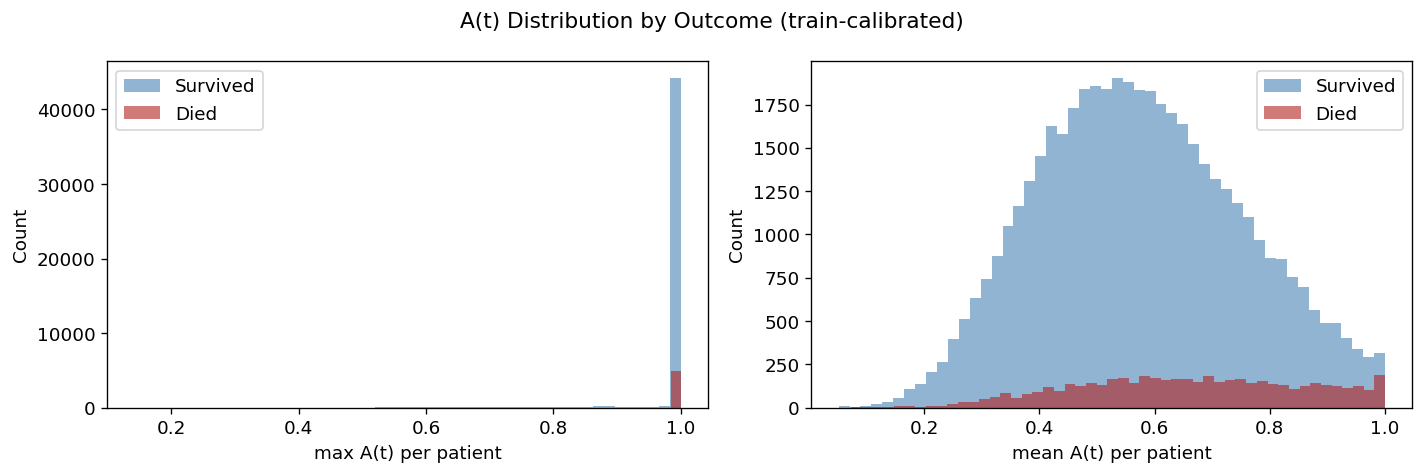

Updated features saved with train-calibrated A(t).


In [20]:
# Merge A(t) into features (drop any old A(t) cols first to avoid duplicates)
features = features.drop(columns=[c for c in ['at_max', 'at_mean', 'at_std', 'at_last'] if c in features.columns])
features = features.merge(at_summary, on="stay_id", how="left")

# A(t) distribution plot (uses train+val+test data, but A(t) values are train-calibrated)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col, title in zip(axes, ["at_max", "at_mean"],
                           ["max A(t) per patient", "mean A(t) per patient"]):
    for label, color in [(0, "steelblue"), (1, "firebrick")]:
        subset = features[features["in_hospital_mortality"] == label][col]
        ax.hist(subset, bins=50, alpha=0.6, color=color,
                label=f"{'Survived' if label==0 else 'Died'}")
    ax.set_xlabel(title)
    ax.set_ylabel("Count")
    ax.legend()
plt.suptitle("A(t) Distribution by Outcome (train-calibrated)", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "at_distribution.png"), dpi=200)
plt.show()

# Save updated features
features.to_csv(os.path.join(PROCESSED_DIR, "features_xgboost.csv"), index=False)
print(f"Updated features saved with train-calibrated A(t).")

---
## Step 7: XGBoost Experiments — All Conditions

Four conditions: Full, NEWS2-set, CAS-4, CAS-4 hybrid A

In [21]:
from xgboost import XGBClassifier

# Define feature sets
cas4_cols = [f"{v}{s}" for v in CORE_VITALS for s in SUFFIXES if f"{v}{s}" in features.columns]
news2_vitals = CORE_VITALS + ["sbp", "gcs_total"]
news2_cols = [f"{v}{s}" for v in news2_vitals for s in SUFFIXES if f"{v}{s}" in features.columns]
full_cols = [c for c in features.columns if c not in
             ["stay_id", "in_hospital_mortality", "gender", "at_max", "at_mean", "at_std", "at_last"]]
at_feature_cols = ["at_max", "at_mean", "at_std", "at_last"]
cas4_hybrid_cols = cas4_cols + [c for c in at_feature_cols if c in features.columns]

FEATURE_SETS = {
    "Full": full_cols,
    "NEWS2-set": news2_cols,
    "CAS-4": cas4_cols,
    "CAS-4 hybrid A": cas4_hybrid_cols,
}

for name, cols in FEATURE_SETS.items():
    print(f"  {name}: {len(cols)} features")

  Full: 65 features
  NEWS2-set: 45 features
  CAS-4: 36 features
  CAS-4 hybrid A: 40 features


In [22]:
# Helper functions
def compute_metrics(y_true, y_prob, name):
    auroc = roc_auc_score(y_true, y_prob)
    auprc = average_precision_score(y_true, y_prob)
    brier = brier_score_loss(y_true, y_prob)
    fpr_arr, tpr_arr, _ = roc_curve(y_true, y_prob)
    fpr80 = fpr_arr[np.argmin(np.abs(tpr_arr - 0.80))]
    fpr90 = fpr_arr[np.argmin(np.abs(tpr_arr - 0.90))]
    return {"name": name, "auroc": auroc, "auprc": auprc, "brier": brier,
            "fpr_at_sens80": fpr80, "fpr_at_sens90": fpr90}

def bootstrap_ci(y_true, y_prob, n_boot=1000):
    scores = []
    n = len(y_true)
    rng = np.random.RandomState(RANDOM_STATE)
    for _ in range(n_boot):
        idx = rng.choice(n, n, replace=True)
        try:
            scores.append(roc_auc_score(y_true[idx], y_prob[idx]))
        except ValueError:
            continue
    return np.percentile(scores, 2.5), np.percentile(scores, 97.5)

scale_pw = (y.loc[train_idx] == 0).sum() / max((y.loc[train_idx] == 1).sum(), 1)
print(f"scale_pos_weight: {scale_pw:.2f}")

scale_pos_weight: 9.05


In [23]:
# Run XGBoost for each condition
all_results = []
all_predictions = {}
roc_data = {}
xgb_models = {}

for cond_name, cols in FEATURE_SETS.items():
    avail = [c for c in cols if c in features.columns]
    scaler = StandardScaler()

    X_tr = scaler.fit_transform(features.loc[train_idx, avail])
    X_va = scaler.transform(features.loc[val_idx, avail])
    X_te = scaler.transform(features.loc[test_idx, avail])
    y_tr = y.loc[train_idx].values
    y_va = y.loc[val_idx].values
    y_te = y.loc[test_idx].values

    model = XGBClassifier(
        n_estimators=500, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=scale_pw, random_state=RANDOM_STATE,
        eval_metric="aucpr", early_stopping_rounds=30, verbosity=0,
    )
    model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)

    y_prob = model.predict_proba(X_te)[:, 1]
    metrics = compute_metrics(y_te, y_prob, f"{cond_name} + XGBoost")
    lo, hi = bootstrap_ci(y_te, y_prob)
    metrics["ci_low"] = lo
    metrics["ci_high"] = hi

    all_results.append(metrics)
    roc_data[metrics["name"]] = (y_te, y_prob)
    all_predictions[metrics["name"]] = y_prob
    xgb_models[cond_name] = (model, scaler, avail)

    print(f"  {cond_name}: AUROC={metrics['auroc']:.4f} ({lo:.3f}-{hi:.3f}), "
          f"AUPRC={metrics['auprc']:.4f}")

  Full: AUROC=0.7961 (0.782-0.812), AUPRC=0.3257
  NEWS2-set: AUROC=0.7738 (0.758-0.791), AUPRC=0.2976
  CAS-4: AUROC=0.7563 (0.739-0.774), AUPRC=0.2862
  CAS-4 hybrid A: AUROC=0.7578 (0.741-0.777), AUPRC=0.2872


---
## Step 8: NEWS2 Scoring Baseline

In [24]:
def news2_score_row(row):
    score = 0
    rr = row.get("resp_rate_last", row.get("resp_rate_mean", np.nan))
    if pd.notna(rr):
        if rr <= 8: score += 3
        elif rr <= 11: score += 1
        elif rr <= 20: score += 0
        elif rr <= 24: score += 2
        else: score += 3
    spo2 = row.get("spo2_last", row.get("spo2_mean", np.nan))
    if pd.notna(spo2):
        if spo2 <= 91: score += 3
        elif spo2 <= 93: score += 2
        elif spo2 <= 95: score += 1
        else: score += 0
    sbp = row.get("sbp_last", row.get("sbp_mean", np.nan))
    if pd.notna(sbp):
        if sbp <= 90: score += 3
        elif sbp <= 100: score += 2
        elif sbp <= 110: score += 1
        elif sbp <= 219: score += 0
        else: score += 3
    hr = row.get("heart_rate_last", row.get("heart_rate_mean", np.nan))
    if pd.notna(hr):
        if hr <= 40: score += 3
        elif hr <= 50: score += 1
        elif hr <= 90: score += 0
        elif hr <= 110: score += 1
        elif hr <= 130: score += 2
        else: score += 3
    temp = row.get("temperature_last", row.get("temperature_mean", np.nan))
    if pd.notna(temp):
        if temp <= 35.0: score += 3
        elif temp <= 36.0: score += 1
        elif temp <= 38.0: score += 0
        elif temp <= 39.0: score += 1
        else: score += 2
    return score

features["news2_total"] = features.apply(news2_score_row, axis=1)

y_te = y.loc[test_idx].values
news2_scores = features.loc[test_idx, "news2_total"].values
metrics_news2 = compute_metrics(y_te, news2_scores / 20.0, "NEWS2 scoring")
lo, hi = bootstrap_ci(y_te, news2_scores / 20.0)
metrics_news2["ci_low"] = lo
metrics_news2["ci_high"] = hi
all_results.append(metrics_news2)
roc_data["NEWS2 scoring"] = (y_te, news2_scores / 20.0)
all_predictions["NEWS2 scoring"] = news2_scores / 20.0

print(f"NEWS2: AUROC={metrics_news2['auroc']:.4f} ({lo:.3f}-{hi:.3f})")

NEWS2: AUROC=0.6385 (0.617-0.659)


---
## Step 9: Feature Reduction Curve — CENTRAL ANALYSIS

Systematically evaluate 9 sensor configurations from full hospital monitoring
to a single pulse sensor. This is the **key new contribution** of the paper.

| Level | Vitals | Sensors | Cost |
|-------|--------|---------|------|
| L1-Full | 50+ features | Hospital ICU | $$$$ |
| L2-AllVitals | All vitals + demo | Bedside | $$$ |
| L3-NEWS2 | HR,RR,SpO2,Temp,SBP,GCS | Nurse + cuff | $$ |
| L4-5vitals | HR,RR,SpO2,Temp,SBP | Wearable + cuff | ~$50 |
| **L5-CAS4** | **HR,RR,SpO2,Temp** | **MAX30102+radar+IR** | **~$30** |
| L5b-CAS4+At | HR,RR,SpO2,Temp + A(t) | Same + domain knowledge | ~$30 |
| L6-3vitals | HR,SpO2,RR | MAX30102 + radar | ~$20 |
| L7-2vitals | HR,SpO2 | MAX30102 only | ~$5 |
| L8-1vital | HR only | Pulse sensor | ~$2 |

In [25]:
import xgboost as xgb

REDUCTION_LEVELS = [
    {'name': 'L1-Full',       'vitals': list(VITAL_SIGN_ITEMS.keys()), 'include_demo': True,  'add_at': False, 'use_all': True,  'cost': '$$$$'},
    {'name': 'L2-AllVitals',  'vitals': list(VITAL_SIGN_ITEMS.keys()), 'include_demo': True,  'add_at': False, 'use_all': False, 'cost': '$$$'},
    {'name': 'L3-NEWS2',      'vitals': ['heart_rate','resp_rate','spo2','temperature','sbp','gcs_total'], 'include_demo': False, 'add_at': False, 'use_all': False, 'cost': '$$'},
    {'name': 'L4-5vitals',    'vitals': ['heart_rate','resp_rate','spo2','temperature','sbp'], 'include_demo': False, 'add_at': False, 'use_all': False, 'cost': '~$50'},
    {'name': 'L5-CAS4',       'vitals': CORE_VITALS, 'include_demo': False, 'add_at': False, 'use_all': False, 'cost': '~$30'},
    {'name': 'L5b-CAS4+At',   'vitals': CORE_VITALS, 'include_demo': False, 'add_at': True,  'use_all': False, 'cost': '~$30'},
    {'name': 'L6-3vitals',    'vitals': ['heart_rate','spo2','resp_rate'], 'include_demo': False, 'add_at': False, 'use_all': False, 'cost': '~$20'},
    {'name': 'L7-2vitals',    'vitals': ['heart_rate','spo2'], 'include_demo': False, 'add_at': False, 'use_all': False, 'cost': '~$5'},
    {'name': 'L8-1vital',     'vitals': ['heart_rate'], 'include_demo': False, 'add_at': False, 'use_all': False, 'cost': '~$2'},
]

reduction_results = []
reduction_predictions = {}

print(f'Testing {len(REDUCTION_LEVELS)} sensor reduction levels')
print('=' * 80)

for level in REDUCTION_LEVELS:
    name = level['name']

    if level['use_all']:
        exclude = {'stay_id', target, 'gender', 'icu_type', 'age_group',
                   'at_max', 'at_mean', 'at_std', 'at_last'}
        cols = [c for c in features.select_dtypes(include=[np.number]).columns if c not in exclude]
    else:
        cols = []
        for v in level['vitals']:
            for s in SUFFIXES:
                col = f'{v}{s}'
                if col in features.columns:
                    cols.append(col)

    if level['include_demo'] and 'age' in features.columns:
        cols.append('age')

    if level['add_at']:
        for c in ['at_max', 'at_mean', 'at_std', 'at_last']:
            if c in features.columns and c not in cols:
                cols.append(c)

    avail = [c for c in cols if c in features.columns]
    if len(avail) == 0:
        print(f'  {name}: NO features, skipping')
        continue

    scaler = StandardScaler()
    X_tr = scaler.fit_transform(features.loc[train_idx, avail])
    X_va = scaler.transform(features.loc[val_idx, avail])
    X_te = scaler.transform(features.loc[test_idx, avail])
    y_tr = y.loc[train_idx].values
    y_va = y.loc[val_idx].values

    model = xgb.XGBClassifier(
        n_estimators=500, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=scale_pw, random_state=RANDOM_STATE,
        eval_metric='aucpr', early_stopping_rounds=30, verbosity=0)
    model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)
    y_prob = model.predict_proba(X_te)[:, 1]

    auroc = roc_auc_score(y_te, y_prob)
    lo, hi = bootstrap_ci(y_te, y_prob)
    auprc = average_precision_score(y_te, y_prob)
    brier = brier_score_loss(y_te, y_prob)

    eps = 1e-7
    p_clip = np.clip(y_prob, eps, 1-eps)
    logit_p = np.log(p_clip / (1-p_clip))
    lr_c = LogisticRegression(fit_intercept=True, max_iter=1000)
    lr_c.fit(logit_p.reshape(-1,1), y_te)
    cal_sl = float(lr_c.coef_[0][0])

    fpr_arr, tpr_arr, _ = roc_curve(y_te, y_prob)
    fpr80 = float(fpr_arr[np.argmin(np.abs(tpr_arr - 0.80))])

    n = len(y_te); pt = 0.10
    y_pred_dca = (y_prob >= pt).astype(int)
    tp = ((y_pred_dca==1) & (y_te==1)).sum()
    fp = ((y_pred_dca==1) & (y_te==0)).sum()
    nb_010 = (tp/n) - (fp/n) * (pt/(1-pt))

    full_auroc = reduction_results[0]['auroc'] if reduction_results else auroc
    pct = auroc / full_auroc * 100 if full_auroc > 0 else 100

    reduction_results.append({
        'level': name, 'n_features': len(avail), 'cost': level['cost'],
        'auroc': round(auroc,4), 'ci_low': round(lo,4), 'ci_high': round(hi,4),
        'auroc_ci': f'{lo:.3f}-{hi:.3f}',
        'auprc': round(auprc,4), 'brier': round(brier,4),
        'cal_slope': round(cal_sl,3), 'fpr_at_sens80': round(fpr80,3),
        'nb_at_pt10': round(nb_010,4), 'pct_of_full': round(pct,1),
    })
    reduction_predictions[name] = y_prob
    all_predictions[f'{name} + XGBoost'] = y_prob

    print(f'  {name:15s} | {len(avail):3d} feat | AUROC={auroc:.4f} ({lo:.3f}-{hi:.3f}) |'
          f' Brier={brier:.4f} | Slope={cal_sl:.3f} | {pct:.1f}% of full')

red_df = pd.DataFrame(reduction_results)
red_df.to_csv(os.path.join(RESULTS_DIR, 'feature_reduction_curve.csv'), index=False)
print(f'\nSaved: {os.path.join(RESULTS_DIR, "feature_reduction_curve.csv")}')

Testing 9 sensor reduction levels
  L1-Full         |  67 feat | AUROC=0.7993 (0.785-0.816) | Brier=0.1491 | Slope=1.102 | 100.0% of full
  L2-AllVitals    |  64 feat | AUROC=0.7985 (0.784-0.814) | Brier=0.1508 | Slope=1.126 | 99.9% of full
  L3-NEWS2        |  45 feat | AUROC=0.7735 (0.757-0.791) | Brier=0.1599 | Slope=1.067 | 96.8% of full
  L4-5vitals      |  45 feat | AUROC=0.7735 (0.757-0.791) | Brier=0.1599 | Slope=1.067 | 96.8% of full
  L5-CAS4         |  36 feat | AUROC=0.7563 (0.739-0.774) | Brier=0.1694 | Slope=1.041 | 94.6% of full
  L5b-CAS4+At     |  40 feat | AUROC=0.7578 (0.741-0.777) | Brier=0.1599 | Slope=0.939 | 94.8% of full
  L6-3vitals      |  27 feat | AUROC=0.7363 (0.718-0.754) | Brier=0.1773 | Slope=1.006 | 92.1% of full
  L7-2vitals      |  18 feat | AUROC=0.6837 (0.664-0.702) | Brier=0.2284 | Slope=2.654 | 85.5% of full
  L8-1vital       |   9 feat | AUROC=0.6347 (0.614-0.655) | Brier=0.2316 | Slope=1.457 | 79.4% of full

Saved: ~/mimic4_study/results/feature

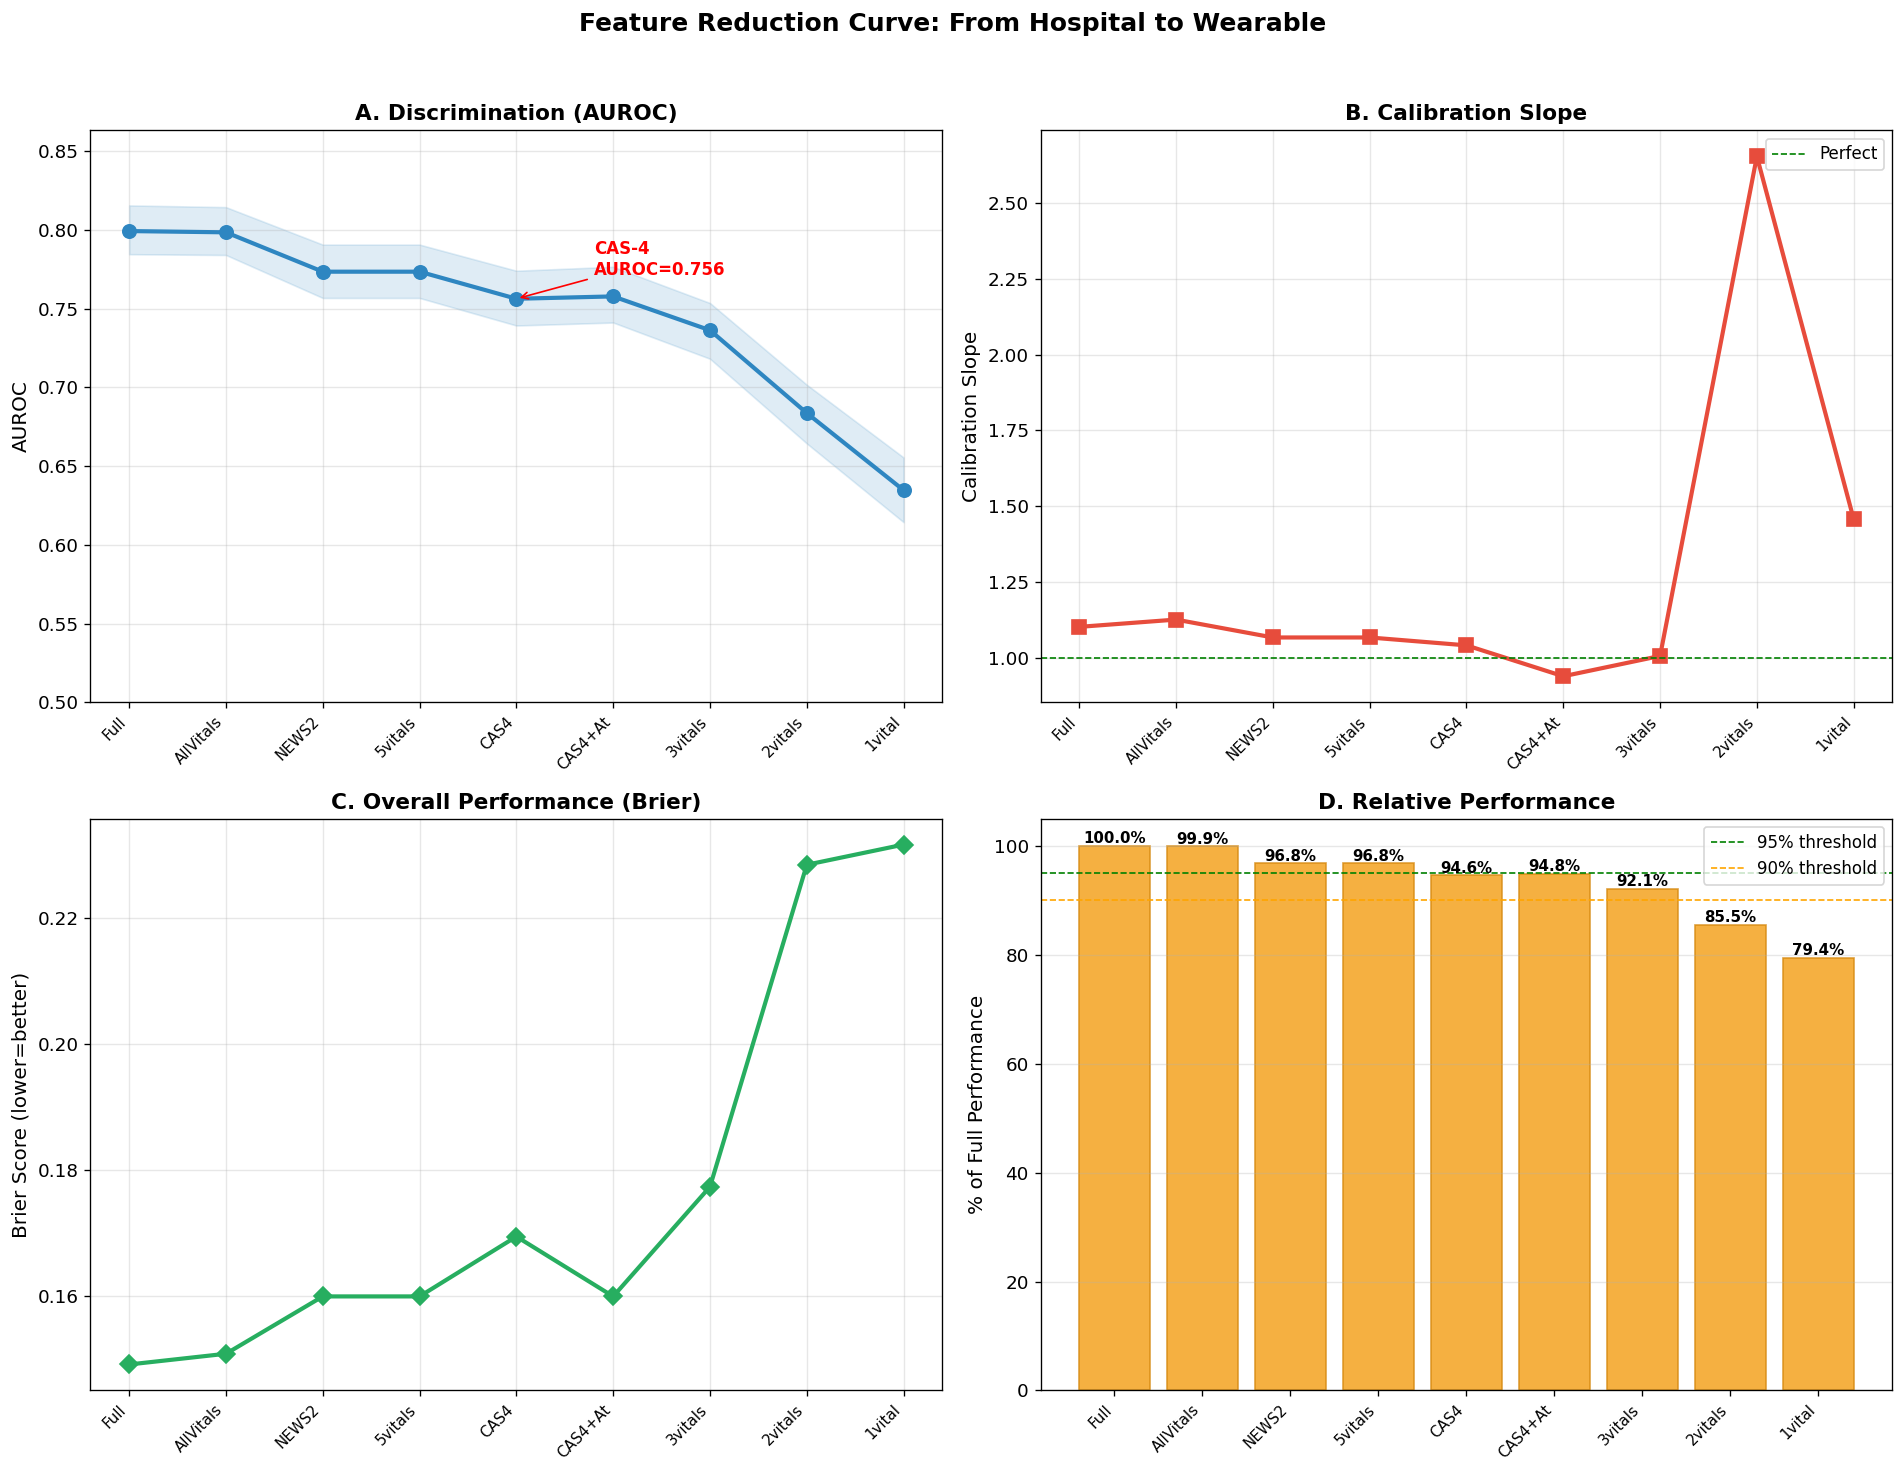


KEY FINDING: Feature Reduction Analysis
  L1-Full        : AUROC=0.7993 (100.0% of full) | Slope=1.102 | Cost=$$$$  
  L2-AllVitals   : AUROC=0.7985 ( 99.9% of full) | Slope=1.126 | Cost=$$$   
  L3-NEWS2       : AUROC=0.7735 ( 96.8% of full) | Slope=1.067 | Cost=$$    
  L4-5vitals     : AUROC=0.7735 ( 96.8% of full) | Slope=1.067 | Cost=~$50  
  L5-CAS4        : AUROC=0.7563 ( 94.6% of full) | Slope=1.041 | Cost=~$30   <<< CAS-4
  L5b-CAS4+At    : AUROC=0.7578 ( 94.8% of full) | Slope=0.939 | Cost=~$30   <<< CAS-4+A(t)
  L6-3vitals     : AUROC=0.7363 ( 92.1% of full) | Slope=1.006 | Cost=~$20  
  L7-2vitals     : AUROC=0.6837 ( 85.5% of full) | Slope=2.654 | Cost=~$5   
  L8-1vital      : AUROC=0.6347 ( 79.4% of full) | Slope=1.457 | Cost=~$2   

Knee point (largest drop): L7-2vitals (delta=0.0526)


In [26]:
# Central figure: feature reduction degradation curve
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
x_labels = [r['level'].split('-',1)[1] if '-' in r['level'] else r['level'] for r in reduction_results]
x = range(len(red_df))

# Panel A: AUROC
ax = axes[0, 0]
ax.plot(x, red_df['auroc'], 'o-', color='#2E86C1', linewidth=2.5, markersize=8)
ax.fill_between(x, red_df['ci_low'], red_df['ci_high'], alpha=0.15, color='#2E86C1')
ax.set_ylabel('AUROC', fontsize=12)
ax.set_title('A. Discrimination (AUROC)', fontsize=13, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=9)
ax.grid(alpha=0.3); ax.set_ylim([0.5, max(red_df['auroc'])*1.08])
for idx_r, row in red_df.iterrows():
    if row['level'] == 'L5-CAS4':
        ax.annotate(f'CAS-4\nAUROC={row["auroc"]:.3f}',
            xy=(idx_r, row['auroc']), xytext=(idx_r+0.8, row['auroc']+0.015),
            arrowprops=dict(arrowstyle='->', color='red'), fontsize=10, color='red', fontweight='bold')

# Panel B: Calibration Slope
ax = axes[0, 1]
ax.plot(x, red_df['cal_slope'], 's-', color='#E74C3C', linewidth=2.5, markersize=8)
ax.axhline(y=1.0, color='green', linestyle='--', linewidth=1, label='Perfect')
ax.set_ylabel('Calibration Slope', fontsize=12)
ax.set_title('B. Calibration Slope', fontsize=13, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=9)
ax.grid(alpha=0.3); ax.legend(fontsize=10)

# Panel C: Brier Score
ax = axes[1, 0]
ax.plot(x, red_df['brier'], 'D-', color='#27AE60', linewidth=2.5, markersize=8)
ax.set_ylabel('Brier Score (lower=better)', fontsize=12)
ax.set_title('C. Overall Performance (Brier)', fontsize=13, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=9)
ax.grid(alpha=0.3)

# Panel D: % of Full
ax = axes[1, 1]
bars = ax.bar(x, red_df['pct_of_full'], color='#F39C12', alpha=0.8, edgecolor='#D68910')
ax.axhline(y=95, color='green', linestyle='--', linewidth=1, label='95% threshold')
ax.axhline(y=90, color='orange', linestyle='--', linewidth=1, label='90% threshold')
ax.set_ylabel('% of Full Performance', fontsize=12)
ax.set_title('D. Relative Performance', fontsize=13, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=9)
ax.grid(alpha=0.3, axis='y'); ax.legend(fontsize=10)
for bar, pct in zip(bars, red_df['pct_of_full']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5, f'{pct:.1f}%',
           ha='center', fontsize=9, fontweight='bold')

fig.suptitle('Feature Reduction Curve: From Hospital to Wearable',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, 'fig_CENTRAL_reduction_curve.png'),
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print('\n' + '='*70)
print('KEY FINDING: Feature Reduction Analysis')
print('='*70)
for _, row in red_df.iterrows():
    marker = ' <<< CAS-4' if row['level']=='L5-CAS4' else ''
    if row['level']=='L5b-CAS4+At': marker = ' <<< CAS-4+A(t)'
    print(f'  {row["level"]:15s}: AUROC={row["auroc"]:.4f} ({row["pct_of_full"]:5.1f}% of full) | '
          f'Slope={row["cal_slope"]:.3f} | Cost={row["cost"]:6s}{marker}')

drops = []
for i in range(1, len(red_df)):
    drop = red_df.iloc[i-1]['auroc'] - red_df.iloc[i]['auroc']
    drops.append((red_df.iloc[i]['level'], round(drop, 4)))
drops.sort(key=lambda x: x[1], reverse=True)
print(f'\nKnee point (largest drop): {drops[0][0]} (delta={drops[0][1]})')

---
## Step 10: Additional Models — CatBoost & Random Forest

CatBoost and Random Forest applied to CAS-4 and CAS-4 hybrid configurations.

In [27]:
# Install catboost if needed
try:
    from catboost import CatBoostClassifier
except ImportError:
    print("Installing catboost...")
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "catboost"])
    from catboost import CatBoostClassifier

from sklearn.ensemble import RandomForestClassifier

NEW_MODELS = {
    'CatBoost': lambda: CatBoostClassifier(
        iterations=500, depth=6, learning_rate=0.05,
        auto_class_weights='Balanced', random_state=RANDOM_STATE, verbose=0),
    'RandomForest': lambda: RandomForestClassifier(
        n_estimators=500, max_depth=10, class_weight='balanced',
        random_state=RANDOM_STATE, n_jobs=-1),
}

for cond_name in ['CAS-4', 'CAS-4 hybrid A']:
    if cond_name not in FEATURE_SETS:
        continue
    cols = FEATURE_SETS[cond_name]
    avail = [c for c in cols if c in features.columns]

    for model_name, model_fn in NEW_MODELS.items():
        scaler = StandardScaler()
        X_tr = scaler.fit_transform(features.loc[train_idx, avail])
        X_te = scaler.transform(features.loc[test_idx, avail])
        y_tr = y.loc[train_idx].values
        y_te_local = y.loc[test_idx].values

        m = model_fn()
        m.fit(X_tr, y_tr)
        y_prob = m.predict_proba(X_te)[:, 1]

        auroc = roc_auc_score(y_te_local, y_prob)
        lo, hi = bootstrap_ci(y_te_local, y_prob)
        auprc = average_precision_score(y_te_local, y_prob)
        brier = brier_score_loss(y_te_local, y_prob)
        fpr_arr, tpr_arr, _ = roc_curve(y_te_local, y_prob)
        fpr80 = float(fpr_arr[np.argmin(np.abs(tpr_arr - 0.80))])

        key = f'{cond_name} + {model_name}'
        all_results.append({
            'name': key, 'auroc': auroc, 'auprc': auprc, 'brier': brier,
            'ci_low': lo, 'ci_high': hi, 'fpr_at_sens80': fpr80, 'fpr_at_sens90': np.nan
        })
        all_predictions[key] = y_prob
        roc_data[key] = (y_te_local, y_prob)
        xgb_models[f'{cond_name}_{model_name}'] = (m, scaler, avail)

        print(f'  {key}: AUROC={auroc:.4f} ({lo:.3f}-{hi:.3f})')

results_df = pd.DataFrame(all_results).sort_values('auroc', ascending=False)
results_df.to_csv(os.path.join(RESULTS_DIR, 'all_model_results.csv'), index=False)
print(f'\nTotal model/condition combos: {len(all_results)}')

  CAS-4 + CatBoost: AUROC=0.7620 (0.746-0.780)
  CAS-4 + RandomForest: AUROC=0.7488 (0.732-0.766)
  CAS-4 hybrid A + CatBoost: AUROC=0.7558 (0.739-0.773)
  CAS-4 hybrid A + RandomForest: AUROC=0.7513 (0.734-0.769)

Total model/condition combos: 9


---
## Step 11: SHAP Feature Importance

For CAS-4 hybrid A + XGBoost. Exports both summary plot and explicit
ranking CSV (mean absolute SHAP value per feature) for use in the paper.

Top 15 SHAP features (CAS-4 hybrid A + XGBoost):
         feature  mean_abs_shap  rank
  resp_rate_mean       0.269087     1
 resp_rate_first       0.204562     2
          at_std       0.192403     3
temperature_mean       0.148442     4
  heart_rate_max       0.114352     5
         at_mean       0.112732     6
 resp_rate_trend       0.091542     7
temperature_last       0.090215     8
 heart_rate_last       0.085811     9
         spo2_cv       0.082406    10
        spo2_std       0.082171    11
       spo2_mean       0.078234    12
         at_last       0.072452    13
heart_rate_trend       0.070290    14
      spo2_trend       0.068659    15


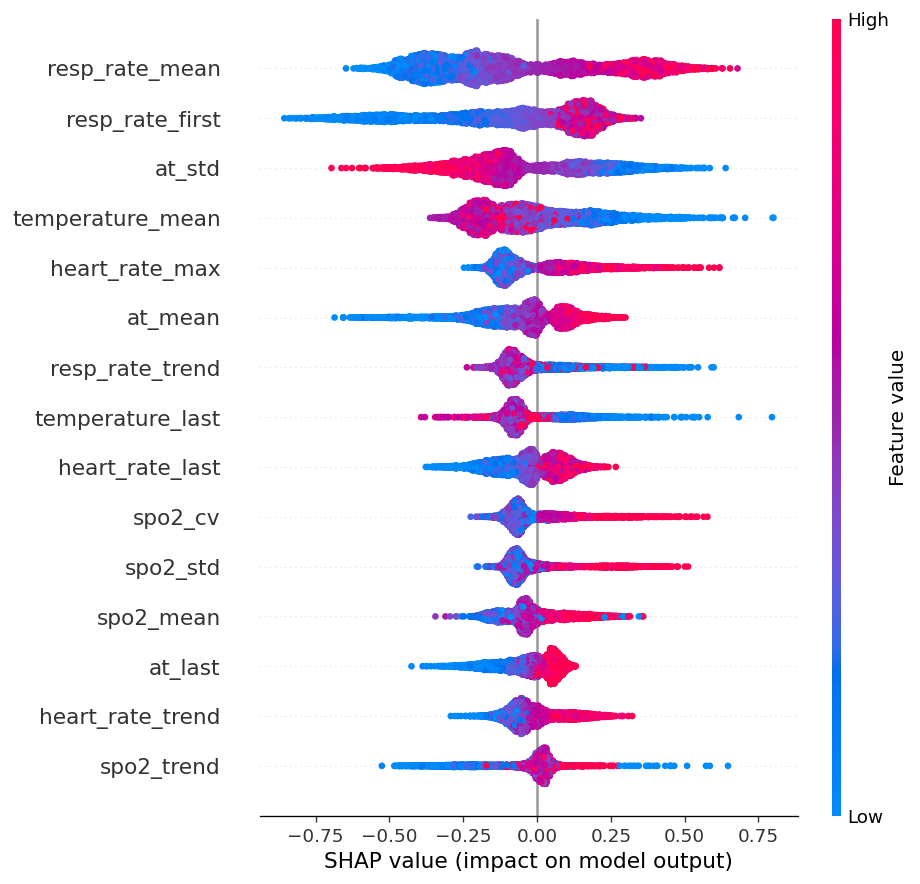

In [28]:
import shap

cas4h_model, cas4h_scaler, cas4h_cols = xgb_models['CAS-4 hybrid A']
X_te_shap = cas4h_scaler.transform(features.loc[test_idx, cas4h_cols])

explainer = shap.TreeExplainer(cas4h_model)
shap_values = explainer.shap_values(X_te_shap)

# v4: Export explicit ranking CSV alongside summary plot
shap_importance = pd.DataFrame({
    'feature': cas4h_cols,
    'mean_abs_shap': np.abs(shap_values).mean(axis=0),
}).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)
shap_importance['rank'] = shap_importance.index + 1
shap_importance.to_csv(os.path.join(RESULTS_DIR, 'shap_ranking.csv'), index=False)

print("Top 15 SHAP features (CAS-4 hybrid A + XGBoost):")
print(shap_importance.head(15).to_string(index=False))

# Summary plot
fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(shap_values, X_te_shap, feature_names=cas4h_cols,
                  max_display=15, show=False)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'fig_shap_cas4_hybrid.png'),
            dpi=300, bbox_inches='tight')
plt.show()

---
## Step 12: Calibration Analysis

Following Van Calster et al. (2019). Metrics: CITL, calibration slope, Brier, Hosmer-Lemeshow.

  Full + XGBoost: slope=1.056, CITL=0.2352, Brier=0.1468
  NEWS2-set + XGBoost: slope=1.043, CITL=0.2598, Brier=0.1594
  CAS-4 + XGBoost: slope=1.041, CITL=0.2770, Brier=0.1694
  CAS-4 hybrid A + XGBoost: slope=0.939, CITL=0.2547, Brier=0.1599
  NEWS2 scoring: slope=0.056, CITL=0.0286, Brier=0.0907
  L1-Full + XGBoost: slope=1.102, CITL=0.2416, Brier=0.1491
  L2-AllVitals + XGBoost: slope=1.126, CITL=0.2457, Brier=0.1508
  L3-NEWS2 + XGBoost: slope=1.067, CITL=0.2623, Brier=0.1599
  L4-5vitals + XGBoost: slope=1.067, CITL=0.2623, Brier=0.1599
  L5-CAS4 + XGBoost: slope=1.041, CITL=0.2770, Brier=0.1694
  L5b-CAS4+At + XGBoost: slope=0.939, CITL=0.2547, Brier=0.1599
  L6-3vitals + XGBoost: slope=1.006, CITL=0.2873, Brier=0.1773
  L7-2vitals + XGBoost: slope=2.654, CITL=0.3777, Brier=0.2284
  L8-1vital + XGBoost: slope=1.457, CITL=0.3781, Brier=0.2316
  CAS-4 + CatBoost: slope=0.929, CITL=0.2593, Brier=0.1636
  CAS-4 + RandomForest: slope=1.549, CITL=0.2471, Brier=0.1454
  CAS-4 hybrid A 

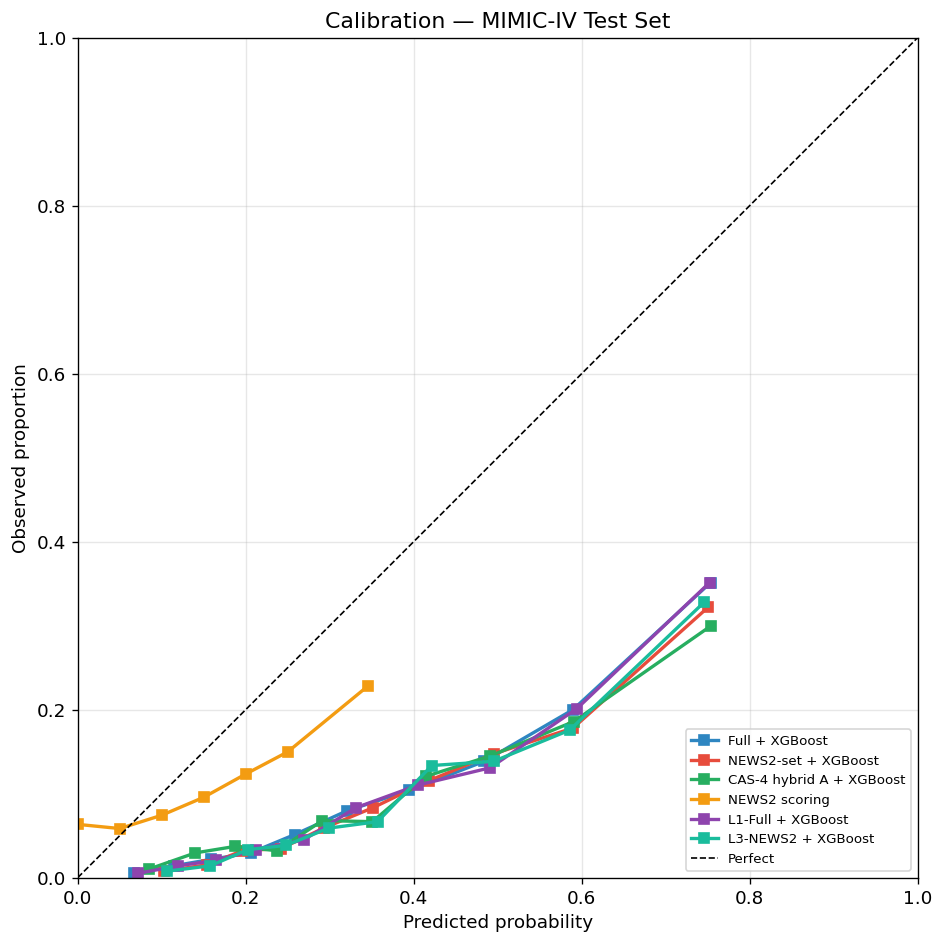

Calibration analysis complete.


In [29]:
from sklearn.calibration import calibration_curve

def cal_slope(y_true, y_prob):
    eps = 1e-7
    p = np.clip(y_prob, eps, 1-eps)
    logit_p = np.log(p/(1-p))
    lr = LogisticRegression(fit_intercept=True, max_iter=1000)
    lr.fit(logit_p.reshape(-1,1), y_true)
    return float(lr.coef_[0][0])

def cal_itl(y_true, y_prob):
    return float(y_prob.mean() - y_true.mean())

def hosmer_lemeshow(y_true, y_prob, g=10):
    df_hl = pd.DataFrame({'y': y_true, 'p': y_prob})
    df_hl['grp'] = pd.qcut(df_hl['p'], g, duplicates='drop')
    obs = df_hl.groupby('grp')['y'].sum()
    exp = df_hl.groupby('grp')['p'].sum()
    n_grp = df_hl.groupby('grp')['y'].count()
    hl = (((obs-exp)**2) / (exp*(1-exp/n_grp)+1e-10)).sum()
    pval = 1 - stats.chi2.cdf(hl, len(obs)-2)
    return float(hl), float(pval)

y_te = y.loc[test_idx].values
cal_results = []

for key, yp in all_predictions.items():
    slope = cal_slope(y_te, yp)
    citl = cal_itl(y_te, yp)
    hl_stat, hl_p = hosmer_lemeshow(y_te, yp)
    brier = brier_score_loss(y_te, yp)
    prev = y_te.mean()
    sc_brier = 1 - brier/(prev*(1-prev)) if prev*(1-prev)>0 else 0
    cal_results.append({'model': key, 'cal_slope': slope, 'citl': citl,
        'brier': brier, 'scaled_brier': sc_brier, 'hl_stat': hl_stat, 'hl_p': hl_p})
    print(f'  {key}: slope={slope:.3f}, CITL={citl:.4f}, Brier={brier:.4f}')

cal_df = pd.DataFrame(cal_results)
cal_df.to_csv(os.path.join(RESULTS_DIR, 'calibration_results.csv'), index=False)

# Calibration plots
plot_keys = [k for k in all_predictions if 'CAS-4 hybrid' in k or 'Full + XGB' in k or 'NEWS2' in k][:6]
colors_cal = ['#2E86C1','#E74C3C','#27AE60','#F39C12','#8E44AD','#1ABC9C']
fig, ax = plt.subplots(figsize=(8,8))
for i, key in enumerate(plot_keys):
    frac, mp = calibration_curve(y_te, all_predictions[key], n_bins=10, strategy='quantile')
    ax.plot(mp, frac, 's-', color=colors_cal[i%6], linewidth=2, label=key)
ax.plot([0,1],[0,1],'k--',linewidth=1,label='Perfect')
ax.set_xlabel('Predicted probability'); ax.set_ylabel('Observed proportion')
ax.set_title('Calibration — MIMIC-IV Test Set')
ax.legend(fontsize=8, loc='lower right'); ax.set_xlim([0,1]); ax.set_ylim([0,1]); ax.grid(alpha=0.3)
plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, 'fig_calibration.png'), dpi=300, bbox_inches='tight')
plt.show()
print('Calibration analysis complete.')

---
## Step 13: Decision Curve Analysis

Following Vickers et al. (2006). Reports explicit net benefit at p_t=0.10
for each model (used in the paper text).


Net Benefit at threshold probability p_t = 0.10
  Full + XGBoost                          : NB = +0.0113
  NEWS2-set + XGBoost                     : NB = +0.0036
  CAS-4 hybrid A + XGBoost                : NB = +0.0068
  NEWS2 scoring                           : NB = +0.0150
  L1-Full + XGBoost                       : NB = +0.0104
  L3-NEWS2 + XGBoost                      : NB = +0.0033
  Treat All                               : NB = -0.0005


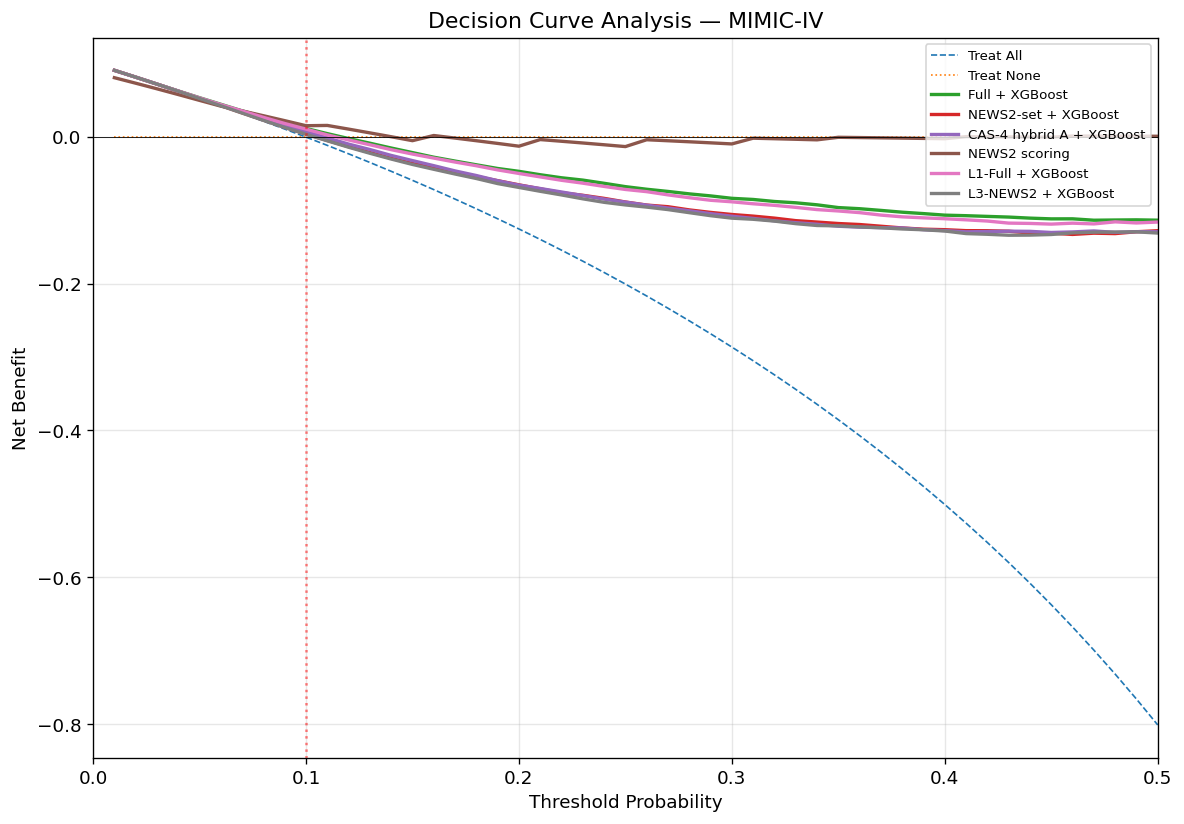


DCA complete.


In [30]:
def net_benefit(y_true, y_prob, pt):
    n = len(y_true)
    if pt >= 1 or pt <= 0: return 0.0
    yp = (y_prob >= pt).astype(int)
    tp = ((yp==1)&(y_true==1)).sum(); fp = ((yp==1)&(y_true==0)).sum()
    return (tp/n) - (fp/n)*(pt/(1-pt))

thresholds = np.arange(0.01, 0.51, 0.01)
prevalence = y_te.mean()
dca_records = []
for pt in thresholds:
    dca_records.append({'threshold':pt, 'model':'Treat All',
                        'net_benefit': prevalence-(1-prevalence)*(pt/(1-pt))})
    dca_records.append({'threshold':pt, 'model':'Treat None', 'net_benefit': 0.0})

dca_keys = [k for k in all_predictions if 'CAS-4 hybrid' in k or 'Full + XGB' in k or 'NEWS2' in k][:6]
for key in dca_keys:
    for pt in thresholds:
        dca_records.append({'threshold':pt, 'model':key,
                            'net_benefit': net_benefit(y_te, all_predictions[key], pt)})

dca_df = pd.DataFrame(dca_records)
dca_df.to_csv(os.path.join(RESULTS_DIR, 'dca_results.csv'), index=False)

# v4: Explicit NB at p_t=0.10 for each model (used in paper text)
print("\n" + "="*60)
print("Net Benefit at threshold probability p_t = 0.10")
print("="*60)
nb_010_records = []
for key in dca_keys + ['Treat All']:
    if key == 'Treat All':
        nb = prevalence - (1-prevalence)*(0.10/(1-0.10))
    else:
        nb = net_benefit(y_te, all_predictions[key], 0.10)
    nb_010_records.append({'model': key, 'nb_at_pt10': round(nb, 4)})
    print(f"  {key:40s}: NB = {nb:+.4f}")
pd.DataFrame(nb_010_records).to_csv(os.path.join(RESULTS_DIR, 'nb_at_pt10.csv'), index=False)

fig, ax = plt.subplots(figsize=(10,7))
styles = {'Treat All':'--', 'Treat None':':'}
for mn in dca_df['model'].unique():
    sub = dca_df[dca_df['model']==mn]
    s = styles.get(mn,'-'); lw = 1 if mn in styles else 2
    ax.plot(sub['threshold'], sub['net_benefit'], s, label=mn, linewidth=lw)
ax.set_xlabel('Threshold Probability'); ax.set_ylabel('Net Benefit')
ax.set_title('Decision Curve Analysis — MIMIC-IV')
ax.legend(loc='upper right', fontsize=8); ax.set_xlim([0,0.5])
ax.axhline(0,color='k',lw=0.5); ax.grid(alpha=0.3)
ax.axvline(0.10, color='red', linestyle=':', alpha=0.5, label='p_t=0.10')
plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, 'fig_dca.png'), dpi=300, bbox_inches='tight')
plt.show()
print('\nDCA complete.')

---
## Step 14: Subgroup Analysis

AUROC + calibration by age, sex, ICU type.

Subgroup model: CAS-4 hybrid A + XGBoost
  age_group=<=55: n=2019, AUROC=0.7851, slope=1.065
  age_group=56-70: n=2614, AUROC=0.7684, slope=0.986
  age_group=>70: n=3165, AUROC=0.7460, slope=0.884
  gender=F: n=3370, AUROC=0.7333, slope=0.851
  gender=M: n=4428, AUROC=0.7763, slope=1.008


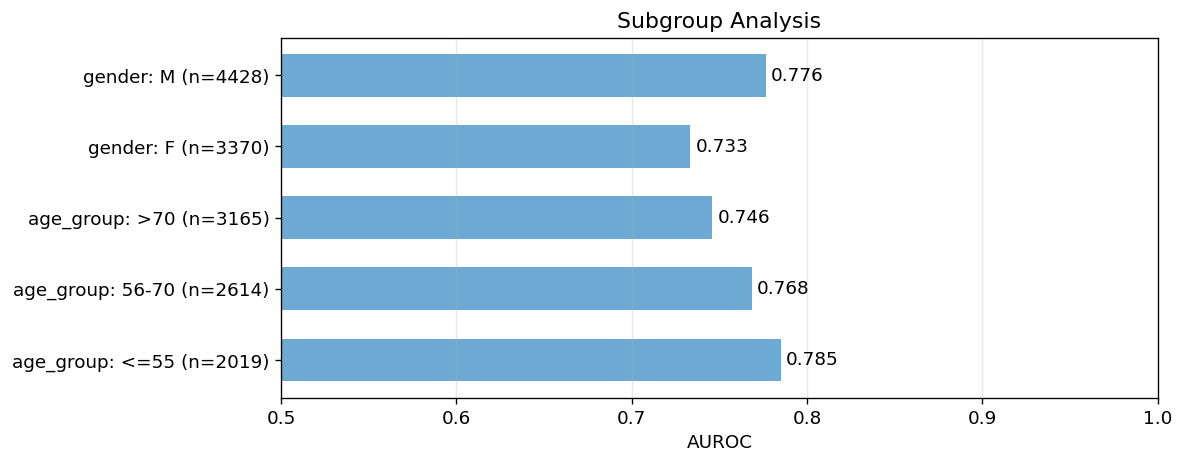

In [31]:
best_key = [k for k in all_predictions if 'CAS-4 hybrid A + XGBoost' in k]
best_key = best_key[0] if best_key else list(all_predictions.keys())[0]
best_prob = all_predictions[best_key]
print(f'Subgroup model: {best_key}')

test_df = features.loc[test_idx].copy().reset_index(drop=True)
if 'age' in test_df.columns:
    test_df['age_group'] = pd.cut(test_df['age'], bins=[0,55,70,200], labels=['<=55','56-70','>70'])

sg_results = []
sg_cols = [c for c in ['age_group','gender'] if c in test_df.columns]
if 'first_careunit' in features.columns:
    sg_cols.append('first_careunit')

for col in sg_cols:
    for grp, gdf in test_df.groupby(col):
        idx = gdf.index.values
        if len(idx) < 50: continue
        yt = y_te[idx]; yp = best_prob[idx]
        if len(np.unique(yt)) < 2: continue
        auroc = roc_auc_score(yt, yp)
        slope = cal_slope(yt, yp)
        sg_results.append({'subgroup':col, 'value':str(grp), 'n':len(idx),
            'events':int(yt.sum()), 'auroc':round(auroc,4), 'cal_slope':round(slope,3)})
        print(f'  {col}={grp}: n={len(idx)}, AUROC={auroc:.4f}, slope={slope:.3f}')

sg_df = pd.DataFrame(sg_results)
sg_df.to_csv(os.path.join(RESULTS_DIR, 'subgroup_results.csv'), index=False)

if len(sg_df) > 0:
    fig, ax = plt.subplots(figsize=(10, max(4, len(sg_df)*0.5)))
    labels = [f"{r['subgroup']}: {r['value']} (n={r['n']})" for _,r in sg_df.iterrows()]
    ax.barh(range(len(sg_df)), sg_df['auroc'], height=0.6, color='#2E86C1', alpha=0.7)
    for j, val in enumerate(sg_df['auroc']):
        ax.text(val+0.003, j, f'{val:.3f}', va='center')
    ax.set_yticks(range(len(sg_df))); ax.set_yticklabels(labels)
    ax.set_xlabel('AUROC'); ax.set_title('Subgroup Analysis')
    ax.grid(alpha=0.3, axis='x'); ax.set_xlim([0.5, 1.0])
    plt.tight_layout()
    fig.savefig(os.path.join(FIGURES_DIR, 'fig_subgroups.png'), dpi=300, bbox_inches='tight')
    plt.show()

---
## Step 15: eICU Multi-Center External Validation

**v4.1 hardening:** Step 15 is now 2 monolithic cells (was 7 in v4.0).

- **Cell A** runs the entire eICU pipeline atomically: download →
  cohort filter → features → hourly A(t). Hard verification at the end
  ensures `eicu_feat` has all A(t) features before Cell B runs.
- **Cell B** applies the MIMIC-IV-trained model with hard assertions
  that refuse to proceed if A(t) features are missing or NaN.

This prevents the v4.0 bug where skipping the A(t) sub-cell caused
silent corruption (model fell back to median-imputed A(t) features).

**v4 fix recap:** A(t) for eICU computed on hourly grid matching
MIMIC-IV (was `at_max=at_mean`, `at_std=0` in v3).
**Without retraining or recalibration of the model.**

In [32]:
# ============================================================
# Step 15 — Cell A: eICU pipeline (download → A(t))
# ============================================================
# This cell is INTENTIONALLY MONOLITHIC. Running it produces a complete
# eicu_feat DataFrame (with A(t) features) or raises an error.
# This prevents the v4.0 bug where a sub-step could be silently skipped.
#
# Phases (announced as we run):
#   1. PhysioNet session
#   2. Download eICU tables (skipped if cached)
#   3. Patient cohort filter (age >=18, LOS >=24h, first stay)
#   4. Vital sign load and plausibility filter
#   5. Hourly grid construction with forward-fill (3h)
#   6. 9 temporal statistical features per vital sign
#   7. Hourly A(t) using train-only weights/pop_stats
#
# Output: eicu_feat with all features INCLUDING at_max, at_mean,
# at_std, at_last. Cell B refuses to apply the model without these.
# ============================================================

print('=' * 60)
print('Step 15: eICU External Validation — Data Preparation')
print('=' * 60)
print('\nPopulation stats (from MIMIC-IV training set):')
for vs in CORE_VITALS:
    print(f"  {vs}: mean={pop_stats[vs]['mean']:.2f}, std={pop_stats[vs]['std']:.2f}")
print(f'\nA(t) weights (train-only): {AT_WEIGHTS}')

# ---- Phase 1: PhysioNet session ----
print('\n[Phase 1/7] PhysioNet session')
_session = globals().get('session')
if _session is None:
    import requests, getpass
    pw_env = os.environ.get('PHYSIONET_PASSWORD')
    password = pw_env if pw_env else getpass.getpass(f'PhysioNet password for {PHYSIONET_USER}: ')
    session = requests.Session()
    login_url = 'https://physionet.org/login/'
    session.get(login_url)
    csrf = session.cookies.get('csrftoken', '')
    resp = session.post(login_url, data={'username': PHYSIONET_USER, 'password': password,
                                          'csrfmiddlewaretoken': csrf},
                        headers={'Referer': login_url})
    print(f'  Session established (status={resp.status_code}).')
else:
    print('  Session reused from earlier.')

# ---- Phase 2: Download ----
print('\n[Phase 2/7] Download eICU tables')
eicu_dir = os.path.join(RAW_DIR, 'eicu-crd')
os.makedirs(eicu_dir, exist_ok=True)

for table in ['patient', 'vitalPeriodic']:
    filename = f'{table}.csv.gz'
    url = f'https://physionet.org/files/eicu-crd/2.0/{filename}'
    filepath = os.path.join(eicu_dir, filename)
    if os.path.exists(filepath) and os.path.getsize(filepath) > 1000:
        print(f'  [SKIP] {filename} ({os.path.getsize(filepath)/1e6:.0f} MB)')
        continue
    print(f'  [GET] {filename}...', end=' ', flush=True)
    resp = session.get(url, stream=True); resp.raise_for_status()
    total = int(resp.headers.get('content-length', 0)); dl = 0
    with open(filepath, 'wb') as f:
        for chunk in resp.iter_content(1024*1024):
            f.write(chunk); dl += len(chunk)
            if total: print(f'\r  [GET] {filename} {dl/1e6:.0f}/{total/1e6:.0f} MB', end='', flush=True)
    print(f'\r  [DONE] {filename} ({os.path.getsize(filepath)/1e6:.0f} MB)' + ' '*20)

# ---- Phase 3: Patient cohort ----
print('\n[Phase 3/7] Patient cohort filter')
eicu_pat = pd.read_csv(os.path.join(eicu_dir, 'patient.csv.gz'), compression='gzip')
print(f'  Raw patient table: {len(eicu_pat)} rows')

eicu_pat['age_num'] = eicu_pat['age'].replace('> 89', '89')
eicu_pat['age_num'] = pd.to_numeric(eicu_pat['age_num'], errors='coerce')
eicu_pat = eicu_pat[eicu_pat['age_num'] >= 18]
eicu_pat = eicu_pat.sort_values('patientunitstayid').drop_duplicates('uniquepid', keep='first')
eicu_pat = eicu_pat[eicu_pat['unitdischargeoffset'] >= 24*60]
eicu_pat['mortality'] = (eicu_pat['hospitaldischargestatus']=='Expired').astype(int)
print(f'  After inclusion criteria: {len(eicu_pat)} stays, '
      f'{eicu_pat["hospitalid"].nunique()} hospitals')

# ---- Phase 4: Vital signs ----
print('\n[Phase 4/7] Vital signs load and plausibility filter')
eicu_vit = pd.read_csv(
    os.path.join(eicu_dir, 'vitalPeriodic.csv.gz'), compression='gzip',
    usecols=['patientunitstayid','observationoffset','heartrate','respiration','sao2','temperature']
)
valid_ids = set(eicu_pat['patientunitstayid'])
eicu_vit = eicu_vit[
    (eicu_vit['patientunitstayid'].isin(valid_ids)) &
    (eicu_vit['observationoffset'] >= 0) &
    (eicu_vit['observationoffset'] <= 24*60)
]
eicu_vit = eicu_vit.rename(columns={'heartrate':'heart_rate','respiration':'resp_rate','sao2':'spo2'})
print(f'  Vital measurements (first 24h): {len(eicu_vit):,}')

for vital_name, (lo, hi) in PLAUSIBLE_RANGES.items():
    if vital_name in eicu_vit.columns:
        bad = (eicu_vit[vital_name] < lo) | (eicu_vit[vital_name] > hi)
        eicu_vit.loc[bad, vital_name] = np.nan

# ---- Phase 5: Hourly grid ----
print('\n[Phase 5/7] Hourly grid construction')
eicu_vit['hour'] = (eicu_vit['observationoffset'] / 60).astype(int).clip(0, 23)
e_hourly_long = eicu_vit.groupby(['patientunitstayid', 'hour'])[CORE_VITALS].mean().reset_index()
e_all_hours = pd.DataFrame({
    'hour': list(range(24)) * len(eicu_pat),
    'patientunitstayid': np.repeat(eicu_pat['patientunitstayid'].values, 24)
})
e_hourly_full = e_all_hours.merge(e_hourly_long, on=['patientunitstayid', 'hour'], how='left')
e_hourly_full = e_hourly_full.sort_values(['patientunitstayid', 'hour'])
for col in CORE_VITALS:
    if col in e_hourly_full.columns:
        e_hourly_full[col] = (
            e_hourly_full.groupby('patientunitstayid')[col]
            .transform(lambda s: s.fillna(method='ffill', limit=3))
        )
print(f'  Hourly grid: {len(e_hourly_full):,} rows')

e_completeness = (
    e_hourly_full.groupby('patientunitstayid')[CORE_VITALS]
    .apply(lambda df: (df.notna().sum() >= 6).all())
)
e_valid = e_completeness[e_completeness].index.tolist()
e_hourly_full = e_hourly_full[e_hourly_full['patientunitstayid'].isin(e_valid)]
print(f'  Stays with >=6h all 4 vitals: {len(e_valid)}')

# ---- Phase 6: Temporal features ----
print('\n[Phase 6/7] Temporal statistical features')
e_feature_rows = []
for sid, group in tqdm(e_hourly_full.groupby('patientunitstayid'), desc='eICU features'):
    row = {'patientunitstayid': sid}
    for vital in CORE_VITALS:
        vals = group[vital].dropna()
        if len(vals) == 0:
            for s in SUFFIXES:
                row[f'{vital}{s}'] = np.nan
            continue
        row[f'{vital}_mean']  = vals.mean()
        row[f'{vital}_std']   = vals.std() if len(vals) > 1 else 0
        row[f'{vital}_min']   = vals.min()
        row[f'{vital}_max']   = vals.max()
        row[f'{vital}_first'] = vals.iloc[0]
        row[f'{vital}_last']  = vals.iloc[-1]
        row[f'{vital}_range'] = vals.max() - vals.min()
        row[f'{vital}_cv']    = (vals.std() / vals.mean()) if vals.mean() != 0 else 0
        if len(vals) >= 2:
            row[f'{vital}_trend'] = np.polyfit(np.arange(len(vals)), vals.values, 1)[0]
        else:
            row[f'{vital}_trend'] = 0.0
    e_feature_rows.append(row)

eicu_feat = pd.DataFrame(e_feature_rows)
eicu_feat = eicu_feat.merge(
    eicu_pat[['patientunitstayid','mortality','age_num','hospitalid']],
    on='patientunitstayid'
)
eicu_feat = eicu_feat.dropna(subset=[f'{vs}_mean' for vs in CORE_VITALS])
print(f'  Feature matrix: {eicu_feat.shape}')

# ---- Phase 7: Hourly A(t) ----
print('\n[Phase 7/7] Hourly A(t) using train-only weights/pop_stats')
# compute_at_hourly auto-detects 'patientunitstayid' for eICU
e_at_df = compute_at_hourly(e_hourly_full, weights, pop_stats, multipliers, CORE_VITALS)
e_at_summary = e_at_df.groupby('patientunitstayid')['at_value'].agg(
    at_max='max', at_mean='mean', at_std='std', at_last='last'
).reset_index()
e_at_summary['at_std'] = e_at_summary['at_std'].fillna(0)

# Defensive: drop any pre-existing A(t) cols and merge fresh
eicu_feat = eicu_feat.drop(columns=[c for c in ['at_max','at_mean','at_std','at_last']
                                      if c in eicu_feat.columns])
eicu_feat = eicu_feat.merge(e_at_summary, on='patientunitstayid', how='left')

# Hard verification before exiting cell
_at_present = [c for c in ['at_max','at_mean','at_std','at_last'] if c in eicu_feat.columns]
assert len(_at_present) == 4, f'A(t) merge failed. Present: {_at_present}'
assert eicu_feat['at_mean'].notna().all(), 'A(t) values contain NaN — merge mismatch'

print(f'\n  A(t) max:  {eicu_feat["at_max"].mean():.3f} +/- {eicu_feat["at_max"].std():.3f}')
print(f'  A(t) std:  {eicu_feat["at_std"].mean():.3f} +/- {eicu_feat["at_std"].std():.3f}')
print(f'  A(t) mean: {eicu_feat["at_mean"].mean():.3f} +/- {eicu_feat["at_mean"].std():.3f}')

# Persist for reproducibility
eicu_feat.to_csv(os.path.join(PROCESSED_DIR, 'eicu_features.csv.gz'),
                 index=False, compression='gzip')

print('\n' + '=' * 60)
print(f'eICU READY: {len(eicu_feat)} stays, {eicu_feat["hospitalid"].nunique()} hospitals')
print(f'  Mortality: {eicu_feat["mortality"].mean():.1%}')
print(f'  A(t) features verified present.')
print(f'  Saved to:  {os.path.join(PROCESSED_DIR, "eicu_features.csv.gz")}')
print('=' * 60)
print('\nProceed to Cell B to apply the MIMIC-IV-trained model.')

Step 15: eICU External Validation — Data Preparation

Population stats (from MIMIC-IV training set):
  heart_rate: mean=84.37, std=15.78
  spo2: mean=96.82, std=1.95
  resp_rate: mean=19.19, std=3.85
  temperature: mean=36.87, std=0.45

A(t) weights (train-only): {'heart_rate': np.float64(0.28473236489176174), 'spo2': np.float64(0.1512462003896862), 'resp_rate': np.float64(0.4435904379762378), 'temperature': np.float64(0.12043099674231439)}

[Phase 1/7] PhysioNet session
  Session established (status=200).

[Phase 2/7] Download eICU tables
  [SKIP] patient.csv.gz (10 MB)
  [SKIP] vitalPeriodic.csv.gz (1784 MB)

[Phase 3/7] Patient cohort filter
  Raw patient table: 200859 rows
  After inclusion criteria: 94896 stays, 208 hospitals

[Phase 4/7] Vital signs load and plausibility filter
  Vital measurements (first 24h): 25,647,467

[Phase 5/7] Hourly grid construction
  Hourly grid: 2,277,504 rows
  Stays with >=6h all 4 vitals: 9402

[Phase 6/7] Temporal statistical features


eICU features:   0%|          | 0/9402 [00:00<?, ?it/s]

  Feature matrix: (9402, 40)

[Phase 7/7] Hourly A(t) using train-only weights/pop_stats

  A(t) max:  0.965 +/- 0.110
  A(t) std:  0.257 +/- 0.094
  A(t) mean: 0.622 +/- 0.217

eICU READY: 9402 stays, 138 hospitals
  Mortality: 16.2%
  A(t) features verified present.
  Saved to:  ~/mimic4_study/processed/eicu_features.csv.gz

Proceed to Cell B to apply the MIMIC-IV-trained model.


All guards passed.
  eicu_feat shape: (9402, 44)
  A(t) features:   ['at_max', 'at_mean', 'at_std', 'at_last'] — all present, no NaN

  Model expects 40 columns
  Available in eICU: 40

eICU CAS-4 hybrid A + XGBoost (v4.1: hourly A(t), no leakage):
  AUROC:        0.7763 (0.763-0.789)
  Cal. slope:   0.965
  Brier score:  0.1949
  N:            9402
  Hospitals:    138
  Mortality:    16.2%


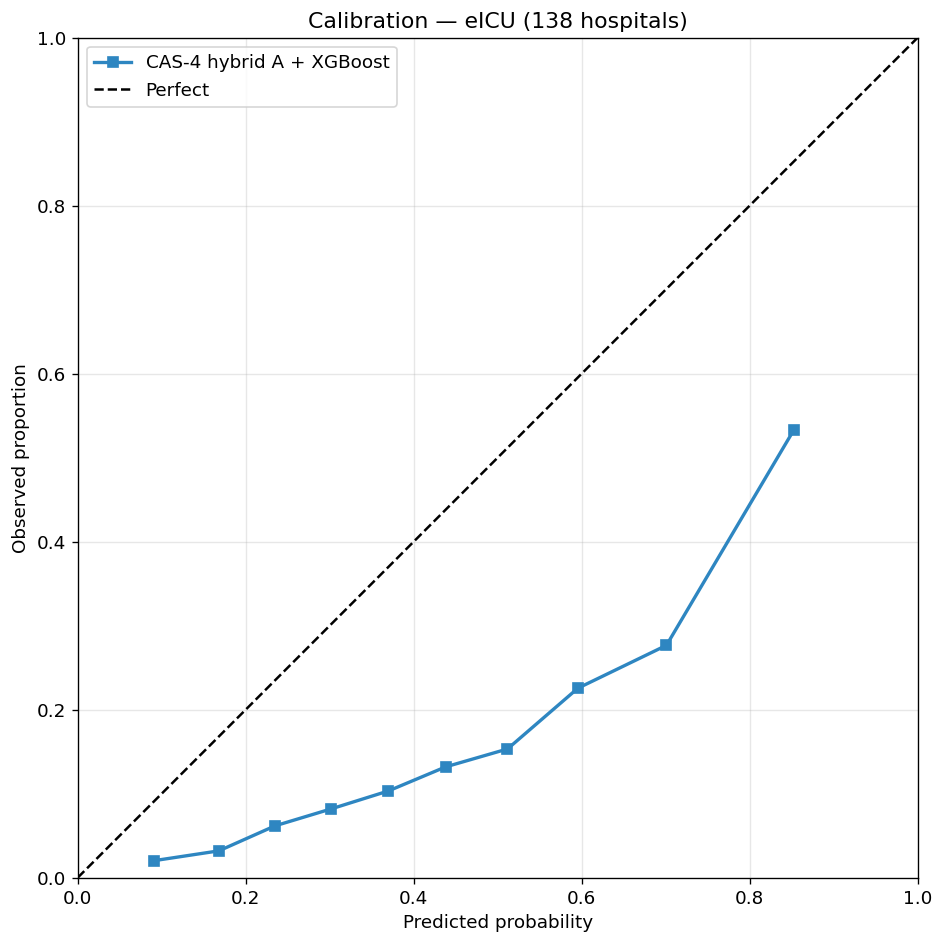


  Saved: ~/mimic4_study/figures/fig_calibration_eicu.png


In [33]:
# ============================================================
# Step 15 — Cell B: Apply MIMIC-IV-trained model to eICU
# ============================================================
# Hard guards prevent the v4.0 silent-failure bug:
#   - Refuses to run if eicu_feat is missing (Cell A not executed)
#   - Refuses to run if A(t) features are absent (Cell A interrupted)
#   - Refuses to run if trained model is missing (Step 7 not executed)
#
# This cell does NOT silently fill A(t) features with median.
# ============================================================

# ---- Hard guards ----
assert 'eicu_feat' in dir() and isinstance(eicu_feat, pd.DataFrame), \
    'eicu_feat is missing. Run Step 15 Cell A (data preparation) first.'

_required_at = ['at_max', 'at_mean', 'at_std', 'at_last']
_missing_at = [c for c in _required_at if c not in eicu_feat.columns]
assert not _missing_at, \
    f'A(t) features missing from eicu_feat: {_missing_at}. Re-run Step 15 Cell A.'
assert eicu_feat['at_mean'].notna().all(), \
    'A(t) values contain NaN. Re-run Step 15 Cell A.'

assert 'xgb_models' in dir() and 'CAS-4 hybrid A' in xgb_models, \
    'Trained CAS-4 hybrid A model not found in xgb_models. Re-run Step 7.'

print('All guards passed.')
print(f'  eicu_feat shape: {eicu_feat.shape}')
print(f'  A(t) features:   {_required_at} — all present, no NaN')

cas4h_model, cas4h_scaler, cas4h_cols = xgb_models['CAS-4 hybrid A']
avail_e = [c for c in cas4h_cols if c in eicu_feat.columns]
non_at_missing = [c for c in cas4h_cols if c not in eicu_feat.columns]

print(f'\n  Model expects {len(cas4h_cols)} columns')
print(f'  Available in eICU: {len(avail_e)}')
if non_at_missing:
    print(f'  Missing in eICU (filled with 0 = scaled mean): {non_at_missing}')
    # These should only be non-CORE vitals (e.g. SBP, GCS) that eICU lacks.
    # Filling with 0 (= scaled mean) represents "feature not measured".
    # A(t) features are guaranteed present by guards above.

# Build matrix in original column order (critical for the trained scaler)
X_eicu_raw = pd.DataFrame(index=eicu_feat.index)
for c in cas4h_cols:
    X_eicu_raw[c] = eicu_feat[c] if c in eicu_feat.columns else 0.0
X_eicu_raw = X_eicu_raw.fillna(0)
X_e = cas4h_scaler.transform(X_eicu_raw.values)

y_eicu = eicu_feat['mortality'].values
y_prob_eicu = cas4h_model.predict_proba(X_e)[:, 1]

# Metrics
auroc_e = roc_auc_score(y_eicu, y_prob_eicu)
lo_e, hi_e = bootstrap_ci(y_eicu, y_prob_eicu)
slope_e = cal_slope(y_eicu, y_prob_eicu)
brier_e = brier_score_loss(y_eicu, y_prob_eicu)

print('\n' + '=' * 60)
print('eICU CAS-4 hybrid A + XGBoost (v4.1: hourly A(t), no leakage):')
print('=' * 60)
print(f'  AUROC:        {auroc_e:.4f} ({lo_e:.3f}-{hi_e:.3f})')
print(f'  Cal. slope:   {slope_e:.3f}')
print(f'  Brier score:  {brier_e:.4f}')
print(f'  N:            {len(eicu_feat)}')
print(f'  Hospitals:    {eicu_feat["hospitalid"].nunique()}')
print(f'  Mortality:    {y_eicu.mean():.1%}')

# Calibration plot
fig, ax = plt.subplots(figsize=(8,8))
frac, mp = calibration_curve(y_eicu, y_prob_eicu, n_bins=10, strategy='quantile')
ax.plot(mp, frac, 's-', color='#2E86C1', linewidth=2, label='CAS-4 hybrid A + XGBoost')
ax.plot([0,1],[0,1],'k--', label='Perfect')
ax.set_xlabel('Predicted probability')
ax.set_ylabel('Observed proportion')
ax.set_title(f'Calibration — eICU ({eicu_feat["hospitalid"].nunique()} hospitals)')
ax.legend(); ax.set_xlim([0,1]); ax.set_ylim([0,1]); ax.grid(alpha=0.3)
plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, 'fig_calibration_eicu.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f'\n  Saved: {os.path.join(FIGURES_DIR, "fig_calibration_eicu.png")}')

---
## Step 16: Save All Results to JSON

Master JSON for Word template placeholders.

In [34]:
from datetime import datetime
from pathlib import Path

RESULTS_FINAL = {
    'metadata': {
        'generated_at': datetime.now().isoformat(),
        'version': 'Scenario_C_v4',
        'changes_from_v3': [
            'A(t) weights and pop_stats computed on training set only (no leakage)',
            'eICU A(t) computed hourly (matching MIMIC-IV methodology)',
            'Bootstrap permutation test executed in pipeline',
            'SHAP ranking exported to CSV',
            'DCA NB at p_t=0.10 explicitly reported',
        ],
    },
    'cohorts': {
        'mimic_iv': {
            'n': int(len(cohort)),
            'mortality_n': int(cohort['in_hospital_mortality'].sum()),
            'mortality_rate': round(float(cohort['in_hospital_mortality'].mean()), 3),
            'median_age': float(cohort['age'].median()) if 'age' in cohort.columns else None,
        },
    },
    'split': {
        'train_n': int(len(train_idx)),
        'val_n': int(len(val_idx)),
        'test_n': int(len(test_idx)),
    },
    'at_calibration': {
        'weights': weights,
        'multipliers': multipliers,
        'pop_stats': {k: {'mean': v['mean'], 'std': v['std']} for k, v in pop_stats.items()},
        'computed_on': 'training_set_only',
    },
    'feature_reduction': red_df.to_dict(orient='records'),
    'model_comparison': results_df.to_dict(orient='records') if 'results_df' in dir() else all_results,
    'calibration': cal_df.to_dict(orient='records'),
    'subgroups': sg_results,
}

if 'shap_importance' in dir():
    RESULTS_FINAL['shap_top15'] = shap_importance.head(15).to_dict(orient='records')

if 'nb_010_records' in dir():
    RESULTS_FINAL['dca_nb_at_pt10'] = nb_010_records

if 'eicu_feat' in dir():
    RESULTS_FINAL['cohorts']['eicu'] = {
        'n': int(len(eicu_feat)),
        'n_hospitals': int(eicu_feat['hospitalid'].nunique()),
        'mortality_rate': round(float(eicu_feat['mortality'].mean()), 3),
    }
if 'auroc_e' in dir():
    RESULTS_FINAL['eicu_validation'] = {
        'auroc': round(float(auroc_e), 4),
        'ci_low': round(float(lo_e), 4),
        'ci_high': round(float(hi_e), 4),
        'cal_slope': round(float(slope_e), 3),
        'brier': round(float(brier_e), 4),
    }

def convert(obj):
    if isinstance(obj, (np.integer,)): return int(obj)
    elif isinstance(obj, (np.floating,)): return float(obj)
    elif isinstance(obj, np.ndarray): return obj.tolist()
    return obj

json_path = os.path.join(RESULTS_DIR, 'all_results.json')
with open(json_path, 'w') as f:
    json.dump(RESULTS_FINAL, f, indent=2, default=convert)

print(f'JSON saved: {json_path}')
print()
print('ALL FILES:')
for d in [RESULTS_DIR, FIGURES_DIR]:
    if os.path.exists(d):
        for fp in sorted(Path(d).glob('*')):
            print(f'  {fp.name:45s} {fp.stat().st_size/1024:.1f} KB')
print('\n=== STEPS 0-16 COMPLETE ===')
print('Continue to Step 17 (bootstrap permutation test).')

JSON saved: ~/mimic4_study/results/all_results.json

ALL FILES:
  all_model_results.csv                         1.4 KB
  all_results.json                              14.9 KB
  at_distribution.png                           66.9 KB
  calibration_results.csv                       2.2 KB
  dca_results.csv                               16.1 KB
  feature_reduction_curve.csv                   0.9 KB
  nb_at_pt10.csv                                0.2 KB
  shap_ranking.csv                              1.1 KB
  subgroup_results.csv                          0.2 KB
  .DS_Store                                     6.0 KB
  fig_CENTRAL_reduction_curve.png               571.7 KB
  fig_calibration.png                           212.1 KB
  fig_calibration_eicu.png                      144.8 KB
  fig_dca.png                                   253.1 KB
  fig_shap_cas4_hybrid.png                      613.3 KB
  fig_subgroups.png                             106.9 KB

=== STEPS 0-16 COMPLETE ===
Continue to 

---
## Step 17: Bootstrap Pairwise AUROC Comparison

Statistical comparison between key sensor configurations to confirm the knee point.
**This must be executed for the paper** — provides p-values cited in the abstract
and central findings.

n=2000 bootstrap iterations, RandomState=42 for reproducibility.

In [35]:
# Bootstrap pairwise AUROC comparison (n=2000, seed=42)
y_te = y.loc[test_idx].values

print('Available predictions from reduction curve:')
for k in sorted(reduction_predictions.keys()):
    auroc = roc_auc_score(y_te, reduction_predictions[k])
    print(f'  {k:18s}: AUROC = {auroc:.4f}')

print('\nAvailable predictions from model comparison:')
for k in sorted(all_predictions.keys()):
    auroc = roc_auc_score(y_te, all_predictions[k])
    print(f'  {k:40s}: AUROC = {auroc:.4f}')

comparisons = [
    ('L5-CAS4',     'L6-3vitals', 'Knee point: 4 vs 3 vitals'),
    ('L5-CAS4',     'L1-Full',    'CAS-4 vs Full'),
    ('L5b-CAS4+At', 'L5-CAS4',    'A(t) benefit'),
    ('L5-CAS4',     'L3-NEWS2',   'CAS-4 vs NEWS2-set'),
]

n_boot = 2000
rng = np.random.RandomState(42)
bootstrap_records = []

print('\n' + '=' * 70)
print('PAIRWISE AUROC COMPARISONS (Bootstrap Permutation, n=2000)')
print('=' * 70)

for key_a, key_b, desc in comparisons:
    if key_a not in reduction_predictions or key_b not in reduction_predictions:
        print(f'\n  {desc}: SKIPPED ({key_a} or {key_b} not found)')
        continue

    pa = reduction_predictions[key_a]
    pb = reduction_predictions[key_b]
    obs_diff = roc_auc_score(y_te, pa) - roc_auc_score(y_te, pb)

    diffs = []
    for _ in range(n_boot):
        idx = rng.choice(len(y_te), len(y_te), replace=True)
        if len(np.unique(y_te[idx])) < 2:
            continue
        try:
            a = roc_auc_score(y_te[idx], pa[idx])
            b = roc_auc_score(y_te[idx], pb[idx])
            diffs.append(a - b)
        except Exception:
            continue

    diffs = np.array(diffs)
    ci_lo, ci_hi = np.percentile(diffs, [2.5, 97.5])

    if obs_diff > 0:
        p_val = float(np.mean(diffs <= 0) * 2)
    elif obs_diff < 0:
        p_val = float(np.mean(diffs >= 0) * 2)
    else:
        p_val = 1.0
    p_val = min(p_val, 1.0)

    sig = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'ns'

    print(f'\n  {desc}:')
    print(f'    {key_a} vs {key_b}')
    print(f'    delta_AUROC = {obs_diff:+.4f} (95% CI: {ci_lo:+.4f} to {ci_hi:+.4f})')
    print(f'    p = {p_val:.6f} {sig}')

    bootstrap_records.append({
        'comparison': desc,
        'key_a': key_a, 'key_b': key_b,
        'auroc_a': round(float(roc_auc_score(y_te, pa)), 4),
        'auroc_b': round(float(roc_auc_score(y_te, pb)), 4),
        'delta_auroc': round(float(obs_diff), 4),
        'ci_low': round(float(ci_lo), 4),
        'ci_high': round(float(ci_hi), 4),
        'p_value': round(p_val, 6),
        'significance': sig,
    })

# Model comparisons
print('\n' + '-' * 70)
print('MODEL COMPARISONS (from Step 10)')
print('-' * 70)

model_comparisons = [
    ('CAS-4 hybrid A + XGBoost', 'CAS-4 + XGBoost', 'A(t) benefit (model comparison)'),
    ('CAS-4 + XGBoost',          'NEWS2 scoring',   'CAS-4 XGB vs NEWS2 scoring'),
]

for key_a, key_b, desc in model_comparisons:
    if key_a not in all_predictions or key_b not in all_predictions:
        print(f'\n  {desc}: SKIPPED ({key_a} or {key_b} not found)')
        continue

    pa = all_predictions[key_a]
    pb = all_predictions[key_b]
    obs_diff = roc_auc_score(y_te, pa) - roc_auc_score(y_te, pb)

    diffs = []
    for _ in range(n_boot):
        idx = rng.choice(len(y_te), len(y_te), replace=True)
        if len(np.unique(y_te[idx])) < 2:
            continue
        try:
            diffs.append(roc_auc_score(y_te[idx], pa[idx]) - roc_auc_score(y_te[idx], pb[idx]))
        except Exception:
            continue

    diffs = np.array(diffs)
    ci_lo, ci_hi = np.percentile(diffs, [2.5, 97.5])
    if obs_diff > 0:
        p_val = float(np.mean(diffs <= 0) * 2)
    elif obs_diff < 0:
        p_val = float(np.mean(diffs >= 0) * 2)
    else:
        p_val = 1.0
    p_val = min(p_val, 1.0)
    sig = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'ns'

    print(f'\n  {desc}:')
    print(f'    {key_a} vs {key_b}')
    print(f'    delta_AUROC = {obs_diff:+.4f} (95% CI: {ci_lo:+.4f} to {ci_hi:+.4f})')
    print(f'    p = {p_val:.6f} {sig}')

    bootstrap_records.append({
        'comparison': desc,
        'key_a': key_a, 'key_b': key_b,
        'auroc_a': round(float(roc_auc_score(y_te, pa)), 4),
        'auroc_b': round(float(roc_auc_score(y_te, pb)), 4),
        'delta_auroc': round(float(obs_diff), 4),
        'ci_low': round(float(ci_lo), 4),
        'ci_high': round(float(ci_hi), 4),
        'p_value': round(p_val, 6),
        'significance': sig,
    })

# Save bootstrap results
boot_df = pd.DataFrame(bootstrap_records)
boot_df.to_csv(os.path.join(RESULTS_DIR, 'bootstrap_auroc_comparisons.csv'), index=False)
print(f'\nSaved: {os.path.join(RESULTS_DIR, "bootstrap_auroc_comparisons.csv")}')

# Append to master JSON
json_path = os.path.join(RESULTS_DIR, 'all_results.json')
if os.path.exists(json_path):
    with open(json_path) as f:
        results_final = json.load(f)
    results_final['bootstrap_comparisons'] = bootstrap_records
    with open(json_path, 'w') as f:
        json.dump(results_final, f, indent=2, default=convert)
    print(f'Updated: {json_path}')

print('\n' + '=' * 70)
print('PIPELINE COMPLETE — use these p-values in the paper.')
print('=' * 70)

Available predictions from reduction curve:
  L1-Full           : AUROC = 0.7993
  L2-AllVitals      : AUROC = 0.7985
  L3-NEWS2          : AUROC = 0.7735
  L4-5vitals        : AUROC = 0.7735
  L5-CAS4           : AUROC = 0.7563
  L5b-CAS4+At       : AUROC = 0.7578
  L6-3vitals        : AUROC = 0.7363
  L7-2vitals        : AUROC = 0.6837
  L8-1vital         : AUROC = 0.6347

Available predictions from model comparison:
  CAS-4 + CatBoost                        : AUROC = 0.7620
  CAS-4 + RandomForest                    : AUROC = 0.7488
  CAS-4 + XGBoost                         : AUROC = 0.7563
  CAS-4 hybrid A + CatBoost               : AUROC = 0.7558
  CAS-4 hybrid A + RandomForest           : AUROC = 0.7513
  CAS-4 hybrid A + XGBoost                : AUROC = 0.7578
  Full + XGBoost                          : AUROC = 0.7961
  L1-Full + XGBoost                       : AUROC = 0.7993
  L2-AllVitals + XGBoost                  : AUROC = 0.7985
  L3-NEWS2 + XGBoost                      : AU